# Credit Card Approval Risk Predictor  
Banks receive a lot of applications for issuance of credit cards. Many of them rejected for many reasons, like high-loan balances, low-income levels, or too many inquiries on an individual’s credit report. Manually analyzing these applications is error-prone and a time-consuming process. This task can be automated with the power of machine learning, In this project, we will be build an automatic credit card approval risk predictor using machine learning techniques, just like the real banks do.
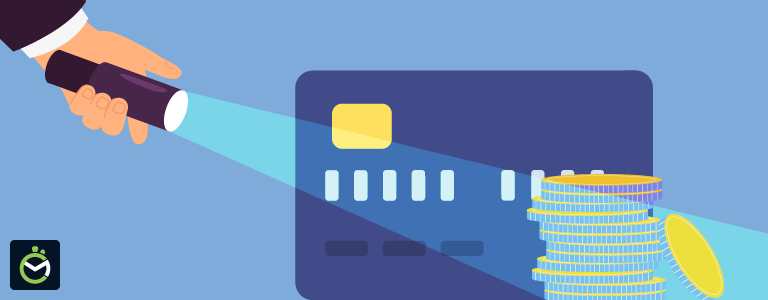

1. ID: Unique Id of the row  
2. CODE_GENDER: Gender of the applicant. M is male and F is female.  
3. FLAG_OWN_CAR: Is an applicant with a car. Y is Yes and N is NO.  
4. FLAG_OWN_REALTY: Is an applicant with realty. Y is Yes and N is No.  
5. CNT_CHILDREN: Count of children.  
6. AMT_INCOME_TOTAL: the amount of the income.  
7. NAME_INCOME_TYPE: The type of income (5 types in total).  
8. NAME_EDUCATION_TYPE: The type of education (5 types in total).  
9. NAME_FAMILY_STATUS: The type of family status (6 types in total).  
10. DAYS_BIRTH: The number of the days from birth (Negative values).  
11. DAYS_EMPLOYED: The number of the days from employed (Negative values). This column has error values.  
12. FLAG_MOBIL: Is an applicant with a mobile. 1 is True and 0 is False.  
13. FLAG_WORK_PHONE: Is an applicant with a work phone. 1 is True and 0 is False.  
14. FLAG_PHONE: Is an applicant with a phone. 1 is True and 0 is False.    
15. FLAG_EMAIL: Is an applicant with a email. 1 is True and 0 is False.  
16. OCCUPATION_TYPE: The type of occupation (19 types in total). This column has missing values.  
17. CNT_FAM_MEMBERS: The count of family members.  


This is a csv file with credit record for a part of ID in application record. We can treat it a file to generate labels for modeling. For the applicants who have a record more than 59 past due, they should be rejected.

After reading the data, we have the following columns.

1. ID: Unique Id of the row in application record.
2. MONTHS_BALANCE: The number of months from record time.
3. STATUS: Credit status for this month.  
  X: No loan for the month  
  C: paid off that month   
  0: 1-29 days past due   
  1: 30-59 days past due   
  2: 60-89 days overdue  
  3: 90-119 days overdue   
  4: 120-149 days overdue   
  5: Overdue or bad debts, write-offs for more than 150 days   

In this project, we’ll be using Credit Card Approval Dataset. The structure of our project will be as follows:
1. To get a basic introduction of our project & What’s the business problem associated with it ?
2. We’ll start by loading and viewing the dataset.
3. To manipulate data, if there are any missing entries in the dataset.
4. To perform exploratory data analysis (EDA) on our dataset.
5. To pre-process data before applying machine learning model to the dataset.
6. To apply machine learning models that can predict if an individual’s application for a credit card will be accepted or not.

In [5]:
!pip install missingno

In [6]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
# data processing, CSV file I/O (e.g. pd.read_csv)

#visualization libraries
import matplotlib.pyplot as plt
import matplotlib.style as style
from matplotlib import colors
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

import plotly.express as px
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import plotly.offline as pyo
from plotly import tools
import seaborn as sns
import missingno as msno
#for visualizing missing data

In [7]:
data = pd.read_csv(r"application_record.csv")
data

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [8]:
data.describe(include="all")

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
count,4.385570e+05,438557,438557,438557,438557.000000,4.385570e+05,438557,438557,438557,438557,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,304354,438557.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,Laborers,NaN
freq,NaN,294440,275459,304074,NaN,NaN,226104,301821,299828,393831,NaN,NaN,NaN,NaN,NaN,NaN,78240,NaN
mean,6.022176e+06,NaN,NaN,NaN,0.427390,1.875243e+05,NaN,NaN,NaN,NaN,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,NaN,2.194465
std,5.716370e+05,NaN,NaN,NaN,0.724882,1.100869e+05,NaN,NaN,NaN,NaN,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,NaN,0.897207
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.610000e+04,NaN,NaN,NaN,NaN,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,NaN,1.000000
25%,5.609375e+06,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
50%,6.047745e+06,NaN,NaN,NaN,0.000000,1.607805e+05,NaN,NaN,NaN,NaN,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000
75%,6.456971e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,NaN,3.000000


In [9]:
print("Number of datapoints for application records: {}".format(len(data)))
print("Number of unique clients in dataset: {}".format(len(data.ID.unique())))

Number of datapoints for application records: 438557
Number of unique clients in dataset: 438510


The number of application records & the unique ID's are not same which depicts the values must be duplicated.

In [10]:
records = pd.read_csv(r"credit_record.csv")
records

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [11]:
print("Number of datapoints for credit records: {}".format(len(records)))
print("Number of unique clients in dataset: {}".format(len(records.ID.unique())))

Number of datapoints for credit records: 1048575
Number of unique clients in dataset: 45985


#### **Before removing duplicated data**

In [12]:
len(set(records['ID']).intersection(set(data['ID'])))

36457

The number of unique ids in the two datasets is not equal.
There are fewer customers than applications in the credit record dataset.  
The intersection is 36,457 customers.

#### **After removing duplicated data**

In [13]:
data

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.iloc[:,1:].duplicated().sum()

np.int64(348472)

In [16]:
print(f'Duplicates in applications data: {data.iloc[:,1:].duplicated().sum()}, ({np.round(100*data.iloc[:,1:].duplicated().sum()/len(data),1)}%)')
print('')
print(f'Duplicates in records data: {records.duplicated().sum()},  ({np.round(100*records.duplicated().sum()/len(records),1)}%)')

Duplicates in applications data: 348472, (79.5%)

Duplicates in records data: 0,  (0.0%)


#### **Drop duplicates**

In [17]:
# Drop duplicates
data=data.drop_duplicates(subset=data.columns[1:], keep='first')

In [18]:
data.shape

(90085, 18)

In [19]:
len(set(records['ID']).intersection(set(data['ID'])))

9709

The number of unique ids in the two datasets is not equal. There are fewer customers than applications in the credit record dataset.  
The intersection is 9709 customers.

In [20]:
records.ID.value_counts()

,count
ID,
5016338,61
5090968,61
5095366,61
5122274,61
5045615,61
...,...
5012689,1
5012728,1
5016441,1


#### **Finding the Cardinality in the data**
Cardinality refers to the distinctiveness or uniqueness of values in a dataset or database column. It represents the number of unique values in a column or a set of columns.

In [21]:
data.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

In [22]:
for col in data.columns:
    print(f"{col} - {data[col].nunique()}")

ID - 90085
CODE_GENDER - 2
FLAG_OWN_CAR - 2
FLAG_OWN_REALTY - 2
CNT_CHILDREN - 12
AMT_INCOME_TOTAL - 866
NAME_INCOME_TYPE - 5
NAME_EDUCATION_TYPE - 5
NAME_FAMILY_STATUS - 5
NAME_HOUSING_TYPE - 6
DAYS_BIRTH - 16379
DAYS_EMPLOYED - 9406
FLAG_MOBIL - 1
FLAG_WORK_PHONE - 2
FLAG_PHONE - 2
FLAG_EMAIL - 2
OCCUPATION_TYPE - 18
CNT_FAM_MEMBERS - 13


In [23]:
[(col, data[col].nunique()) for col in data.columns]

[('ID', 90085),
 ('CODE_GENDER', 2),
 ('FLAG_OWN_CAR', 2),
 ('FLAG_OWN_REALTY', 2),
 ('CNT_CHILDREN', 12),
 ('AMT_INCOME_TOTAL', 866),
 ('NAME_INCOME_TYPE', 5),
 ('NAME_EDUCATION_TYPE', 5),
 ('NAME_FAMILY_STATUS', 5),
 ('NAME_HOUSING_TYPE', 6),
 ('DAYS_BIRTH', 16379),
 ('DAYS_EMPLOYED', 9406),
 ('FLAG_MOBIL', 1),
 ('FLAG_WORK_PHONE', 2),
 ('FLAG_PHONE', 2),
 ('FLAG_EMAIL', 2),
 ('OCCUPATION_TYPE', 18),
 ('CNT_FAM_MEMBERS', 13)]

In [24]:
unique_counts = pd.DataFrame.from_records([(col, data[col].nunique()) for col in data.columns],
                          columns=['Column_Name', 'Num_Unique']).sort_values(by=['Num_Unique'])
unique_counts

,Column_Name,Num_Unique
12,FLAG_MOBIL,1
1,CODE_GENDER,2
3,FLAG_OWN_REALTY,2
2,FLAG_OWN_CAR,2
14,FLAG_PHONE,2
13,FLAG_WORK_PHONE,2
15,FLAG_EMAIL,2
7,NAME_EDUCATION_TYPE,5
8,NAME_FAMILY_STATUS,5
6,NAME_INCOME_TYPE,5


In [25]:
unique_counts = pd.DataFrame.from_records([(col, records[col].nunique()) for col in records.columns],
                          columns=['Column_Name', 'Num_Unique']).sort_values(by=['Num_Unique'])
unique_counts

,Column_Name,Num_Unique
2,STATUS,8
1,MONTHS_BALANCE,61
0,ID,45985


In [26]:
data["FLAG_MOBIL"].unique()

array([1])

From the above observations it was observed that "FLAG_MOBIL" is having only one value in the entire column which indicates that there is a singularity in the data in that particular column. So this values are going to be the same no matter whichever customer is taken into consideration. We can try to eliminate this variable as the values are not changing so contribution of this variable is quite negligible.

In [27]:
data.drop(["FLAG_MOBIL"],axis=1,inplace=True)

In [28]:
data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,0,0,0,NaN,1.0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,Accountants,2.0


In [29]:
data.shape

(90085, 17)

## **Handling Missing Values**
Missing values can pose challenges when working with data, as they can affect data integrity, accuracy, and validity of analysis or modeling results. It is important to handle missing values appropriately in order to avoid biased or incomplete analysis.

In [30]:
data.isnull().sum()/len(data)*100

,0
ID,0.000000
CODE_GENDER,0.000000
FLAG_OWN_CAR,0.000000
FLAG_OWN_REALTY,0.000000
CNT_CHILDREN,0.000000
AMT_INCOME_TOTAL,0.000000
NAME_INCOME_TYPE,0.000000
NAME_EDUCATION_TYPE,0.000000
NAME_FAMILY_STATUS,0.000000
NAME_HOUSING_TYPE,0.000000


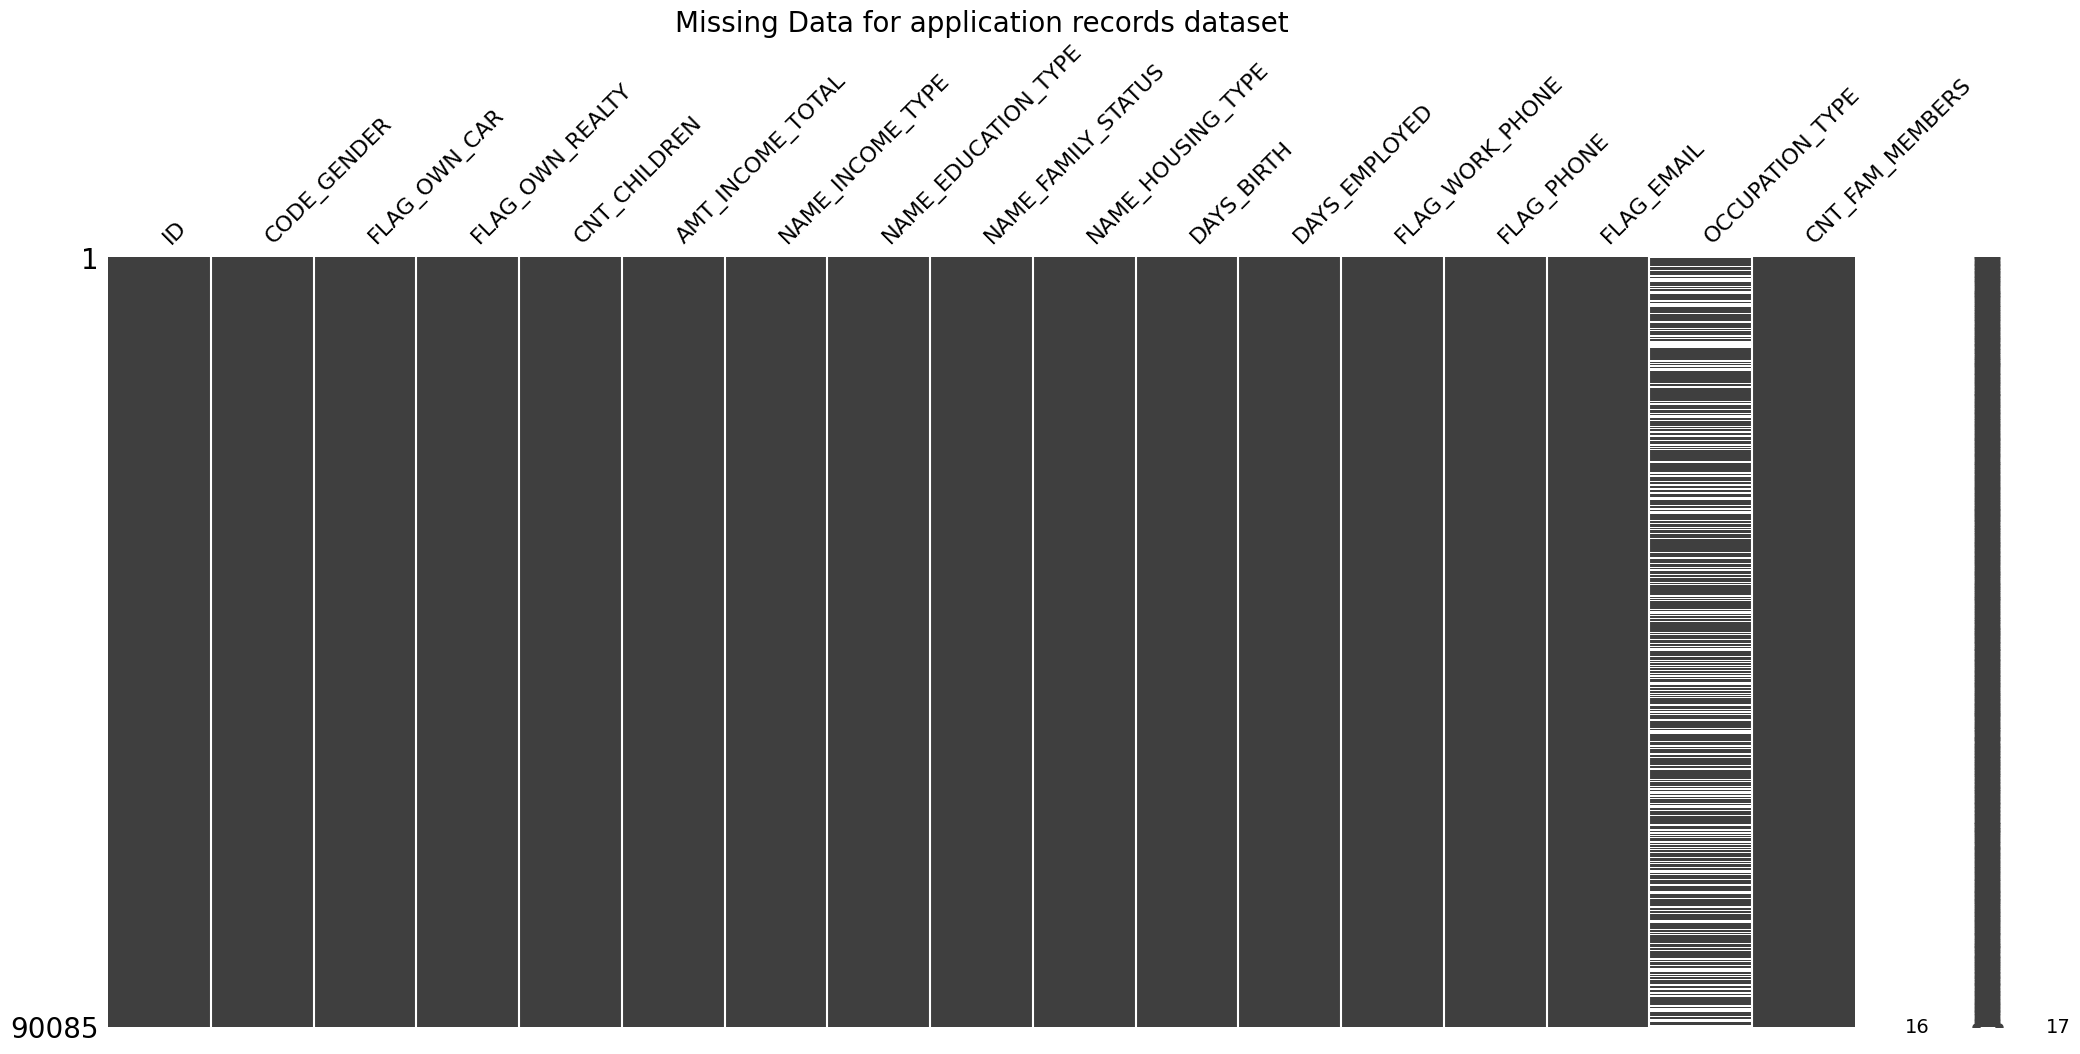

In [31]:
missing = msno.matrix(data)
missing.set_title("Missing Data for application records dataset",fontsize=20);

As we can observe from above that "OCCUPATION_TYPE" is the only column from appplications data having large set of missing values.Appropriate handling of missing values can help ensure the integrity and accuracy of data analyses and modeling results.

In [32]:
records.isnull().sum()

,0
ID,0
MONTHS_BALANCE,0
STATUS,0


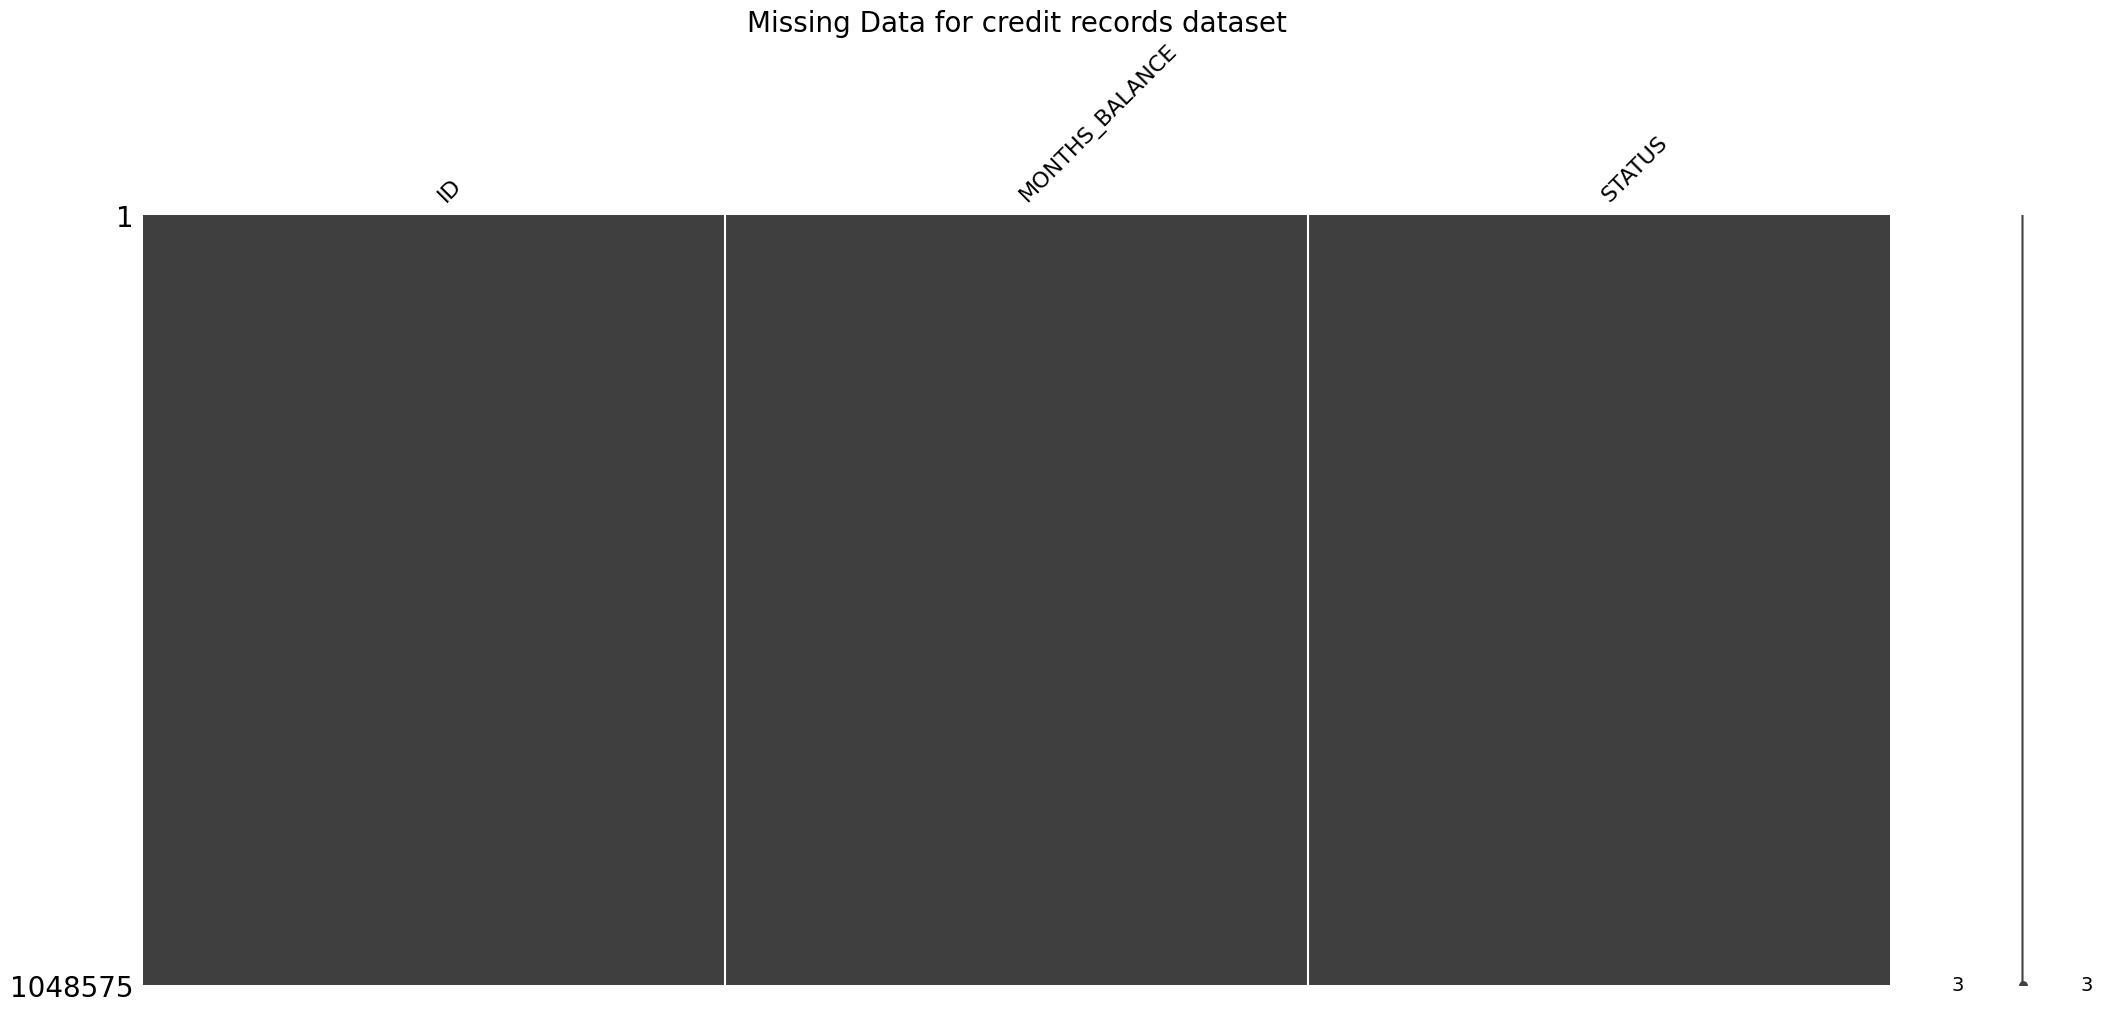

In [33]:
missing2 = msno.matrix(records)

missing2.set_title("Missing Data for credit records dataset",fontsize=20);

In [34]:
data['OCCUPATION_TYPE'].value_counts()

,count
OCCUPATION_TYPE,
Laborers,16624
Sales staff,9123
Core staff,8091
Managers,6675
Drivers,5860
High skill tech staff,3357
Accountants,3034
Medicine staff,2484
Cooking staff,1764


In [35]:
# Fill missing values
data['OCCUPATION_TYPE']=data['OCCUPATION_TYPE'].fillna(value='Other', inplace=True)

As droping the missing values completely can lead to huge data loss. So instead of dropping we will try to fill the missing values as "Other", so the data loss can also be prevented & missing values will also get handled appropriately.


In [36]:
data.isna().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


In [37]:
records.head(20)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [38]:
records.STATUS.value_counts()

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


#### **Converting data in proper format**

In [39]:
records.dtypes

,0
ID,int64
MONTHS_BALANCE,int64
STATUS,object


In [40]:
records.STATUS.unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [41]:
records["STATUS"]=records["STATUS"].astype("object")
records.dtypes
records.STATUS.unique()

array(['X', '0', 'C', '1', '2', '3', '4', '5'], dtype=object)

In [42]:
# target=1 (high risk) if there is at least
#one month where user is late on payments by 30 days or more

records['target']=records['STATUS']
records['target'].replace('X', 0, inplace=True)
records['target'].replace('C', 0, inplace=True)
records.loc[records["target"]=="X",'target'] = 0 #
records.loc[records["target"]=="C",'target'] = 0 #
records['target']=records['target'].astype(int)
records.loc[records['target']>=1,'target'] = 1

records

,ID,MONTHS_BALANCE,STATUS,target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
...,...,...,...,...
1048570,5150487,-25,C,0
1048571,5150487,-26,C,0
1048572,5150487,-27,C,0
1048573,5150487,-28,C,0


In [43]:
records.dtypes

,0
ID,int64
MONTHS_BALANCE,int64
STATUS,object
target,int64


In [44]:
records.target.value_counts()

,count
target,
0,1034381
1,14194


In [45]:
print("Number of datapoints for application records: {}".format(len(records)))
print("Number of unique clients in dataset: {}".format(len(records.ID.unique())))

Number of datapoints for application records: 1048575
Number of unique clients in dataset: 45985


In [46]:
records.head(10)

,ID,MONTHS_BALANCE,STATUS,target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
5,5001712,-1,C,0
6,5001712,-2,C,0
7,5001712,-3,C,0
8,5001712,-4,C,0
9,5001712,-5,C,0


In [47]:
records.groupby(['ID'])['target'].agg(max).reset_index()

,ID,target
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0
...,...,...
45980,5150482,0
45981,5150483,0
45982,5150484,0
45983,5150485,0


In [48]:
df=pd.DataFrame(records.groupby(['ID'])['target'].agg(max)).reset_index()

In [49]:
df.head()

,ID,target
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [50]:
df.target.value_counts()

,count
target,
0,40635
1,5350


In [51]:
new_df=pd.merge(data, df, how='inner', on=['ID'])

In [52]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,None,2.0,1
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,None,2.0,0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,None,1.0,0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,0,0,0,None,1.0,0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,None,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-20600,-198,0,0,0,None,2.0,1
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15837,-2694,1,1,0,None,2.0,1
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-19101,-1721,0,0,0,None,2.0,1
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,0,1,1,None,2.0,1


In [53]:
new_df.shape

(9709, 18)

In [54]:
records

,ID,MONTHS_BALANCE,STATUS,target
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0
...,...,...,...,...
1048570,5150487,-25,C,0
1048571,5150487,-26,C,0
1048572,5150487,-27,C,0
1048573,5150487,-28,C,0


In [55]:
# Extracting how many months account has been opened for
start_df=pd.DataFrame(records.groupby(['ID'])['MONTHS_BALANCE'].agg(min)).reset_index()

# Rename column
start_df.rename(columns={'MONTHS_BALANCE':'ACCOUNT_LENGTH'}, inplace=True)

# Make entries positive
start_df['ACCOUNT_LENGTH']=-start_df['ACCOUNT_LENGTH']
start_df

,ID,ACCOUNT_LENGTH
0,5001711,3
1,5001712,18
2,5001713,21
3,5001714,14
4,5001715,59
...,...,...
45980,5150482,28
45981,5150483,17
45982,5150484,12
45983,5150485,1


In [56]:
start_df

,ID,ACCOUNT_LENGTH
0,5001711,3
1,5001712,18
2,5001713,21
3,5001714,14
4,5001715,59
...,...,...
45980,5150482,28
45981,5150483,17
45982,5150484,12
45983,5150485,1


In [57]:
# Merge dataframes on ID
new_df=pd.merge(new_df, start_df, how='inner', on=['ID'])

In [58]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,None,2.0,1,15
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,None,2.0,0,29
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,None,1.0,0,4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,0,0,0,None,1.0,0,20
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,None,2.0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-20600,-198,0,0,0,None,2.0,1,20
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15837,-2694,1,1,0,None,2.0,1,19
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-19101,-1721,0,0,0,None,2.0,1,21
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,0,1,1,None,2.0,1,32


In [59]:
new_df.describe(include="all")

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH
count,9.709000e+03,9709,9709,9709,9709.000000,9.709000e+03,9709,9709,9709,9709,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,0,9709.000000,9709.000000,9709.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,6323,6139,6520,NaN,NaN,4960,6761,6530,8684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5.076105e+06,NaN,NaN,NaN,0.422804,1.812282e+05,NaN,NaN,NaN,NaN,-15991.811618,61732.846328,0.217427,0.287671,0.087548,NaN,2.182614,0.132145,27.270059
std,4.080270e+04,NaN,NaN,NaN,0.767019,9.927731e+04,NaN,NaN,NaN,NaN,4246.224468,139656.322958,0.412517,0.452700,0.282650,NaN,0.932918,0.338666,16.648057
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.700000e+04,NaN,NaN,NaN,NaN,-25152.000000,-15713.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000
25%,5.036955e+06,NaN,NaN,NaN,0.000000,1.125000e+05,NaN,NaN,NaN,NaN,-19565.000000,-2995.000000,0.000000,0.000000,0.000000,NaN,2.000000,0.000000,13.000000
50%,5.069449e+06,NaN,NaN,NaN,0.000000,1.575000e+05,NaN,NaN,NaN,NaN,-15611.000000,-1374.000000,0.000000,0.000000,0.000000,NaN,2.000000,0.000000,26.000000
75%,5.112986e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12440.000000,-339.000000,0.000000,1.000000,0.000000,NaN,3.000000,0.000000,41.000000


In [60]:
round(-data["DAYS_BIRTH"]/365,0)

,DAYS_BIRTH
0,33.0
2,59.0
3,52.0
7,62.0
10,46.0
...,...
438541,37.0
438545,52.0
438547,30.0
438552,62.0


As you can see that "DAYS_BIRTH" column is giving the information about the age of individual,but here it's not in a proper format . So we will try to convert it into a proper form to make it more understandable.

In [61]:
# Create age feature
new_df['AGE']=round(-new_df['DAYS_BIRTH']/365,0)
#The number 365.2425 is used because it represents the average length of a tropical year,
#which is the time it takes for the Earth to complete one orbit around the Sun.

In [62]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,0,0,None,2.0,1,15,33.0
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,0,0,0,None,2.0,0,29,59.0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,0,1,1,None,1.0,0,4,52.0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,0,0,0,None,1.0,0,20,62.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,None,2.0,0,5,46.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-20600,-198,0,0,0,None,2.0,1,20,56.0
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-15837,-2694,1,1,0,None,2.0,1,19,43.0
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-19101,-1721,0,0,0,None,2.0,1,21,52.0
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-12387,-1325,0,1,1,None,2.0,1,32,34.0


As now we have converted the "DAYS_BIRTH" column into a proper format & named it as "AGE". So now both are somewhat sharing same set of information in the data. So we will drop out the "DAYS_BIRTH" for betterment of the data.

In [63]:
new_df.drop(["DAYS_BIRTH"],axis=1,inplace=True)

In [64]:
new_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH,AGE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,0,0,None,2.0,1,15,33.0
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,0,0,0,None,2.0,0,29,59.0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,0,1,1,None,1.0,0,4,52.0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,365243,0,0,0,None,1.0,0,20,62.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-769,1,1,1,None,2.0,0,5,46.0


In [65]:
new_df.DAYS_EMPLOYED.describe()

,DAYS_EMPLOYED
count,9709.000000
mean,61732.846328
std,139656.322958
min,-15713.000000
25%,-2995.000000
50%,-1374.000000
75%,-339.000000
max,365243.000000


In [66]:
new_df[-new_df["DAYS_EMPLOYED"]>0]["NAME_INCOME_TYPE"].value_counts()

,count
NAME_INCOME_TYPE,
Working,4960
Commercial associate,2312
State servant,722
Pensioner,16
Student,3


In [67]:
# Create unemployed indicator
new_df['UNEMPLOYED']=0
new_df.loc[-new_df['DAYS_EMPLOYED']<0,'UNEMPLOYED']=1

In [68]:
new_df.head(10)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH,AGE,UNEMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,0,0,None,2.0,1,15,33.0,0
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,0,0,0,None,2.0,0,29,59.0,0
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,0,1,1,None,1.0,0,4,52.0,0
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,365243,0,0,0,None,1.0,0,20,62.0,1
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-769,1,1,1,None,2.0,0,5,46.0,0
5,5008819,M,Y,Y,0,135000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-1194,0,0,0,None,2.0,0,17,49.0,0
6,5008825,F,Y,N,0,130500.0,Working,Incomplete higher,Married,House / apartment,-1103,0,0,0,None,2.0,1,25,29.0,0
7,5008830,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,-1469,0,1,0,None,2.0,1,31,27.0,0
8,5008834,F,N,Y,1,112500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-1620,0,0,0,None,2.0,0,44,30.0,0
9,5008836,M,Y,Y,3,270000.0,Working,Secondary / secondary special,Married,House / apartment,-1163,0,0,0,None,5.0,0,24,35.0,0


In [69]:
round(-new_df["DAYS_EMPLOYED"]/365,1)

,DAYS_EMPLOYED
0,12.4
1,3.1
2,8.4
3,-1000.7
4,2.1
...,...
9704,0.5
9705,7.4
9706,4.7
9707,3.6


As we can observe the no. of the days the applicant is working i.e. "DAYS_EMPLOYED" is not in proper format, So we will try to convert it in a proper format.

In [70]:
# Create years employed feature
new_df['YEARS_EMPLOYED']=round(-new_df['DAYS_EMPLOYED']/365,1)
new_df.loc[new_df['YEARS_EMPLOYED']<0,'YEARS_EMPLOYED']=0
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH,AGE,UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,None,2.0,1,15,33.0,0,12.4
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,None,2.0,0,29,59.0,0,3.1
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0,1,1,None,1.0,0,4,52.0,0,8.4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,...,0,0,0,None,1.0,0,20,62.0,1,0.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,...,1,1,1,None,2.0,0,5,46.0,0,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,...,0,0,0,None,2.0,1,20,56.0,0,0.5
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,...,1,1,0,None,2.0,1,19,43.0,0,7.4
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,...,0,0,0,None,2.0,1,21,52.0,0,4.7
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,...,0,1,1,None,2.0,1,32,34.0,0,3.6


In [71]:
pd.set_option('display.max_columns',None)

In [72]:
new_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH,AGE,UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-4542,1,0,0,None,2.0,1,15,33.0,0,12.4
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-1134,0,0,0,None,2.0,0,29,59.0,0,3.1
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-3051,0,1,1,None,1.0,0,4,52.0,0,8.4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,365243,0,0,0,None,1.0,0,20,62.0,1,0.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-769,1,1,1,None,2.0,0,5,46.0,0,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,F,N,N,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,-198,0,0,0,None,2.0,1,20,56.0,0,0.5
9705,5149055,F,N,Y,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-2694,1,1,0,None,2.0,1,19,43.0,0,7.4
9706,5149729,M,Y,Y,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,-1721,0,0,0,None,2.0,1,21,52.0,0,4.7
9707,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,-1325,0,1,1,None,2.0,1,32,34.0,0,3.6


As now we have converted the "DAYS_EMPLOYED" column into a proper format & named it as "YEARS_EMPLOYED". So now both are somewhat sharing same set of information in the data. So we will drop out the "DAYS_EMPLOYED" for betterment of the data.

In [73]:
new_df.drop('DAYS_EMPLOYED', axis=1, inplace=True)

In [74]:
new_df.head(10)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,target,ACCOUNT_LENGTH,AGE,UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,1,15,33.0,0,12.4
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,None,2.0,0,29,59.0,0,3.1
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,None,1.0,0,4,52.0,0,8.4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,0,20,62.0,1,0.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,0,5,46.0,0,2.1
5,5008819,M,Y,Y,0,135000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,0,0,0,None,2.0,0,17,49.0,0,3.3
6,5008825,F,Y,N,0,130500.0,Working,Incomplete higher,Married,House / apartment,0,0,0,None,2.0,1,25,29.0,0,3.0
7,5008830,F,N,Y,0,157500.0,Working,Secondary / secondary special,Married,House / apartment,0,1,0,None,2.0,1,31,27.0,0,4.0
8,5008834,F,N,Y,1,112500.0,Working,Secondary / secondary special,Single / not married,House / apartment,0,0,0,None,2.0,0,44,30.0,0,4.4
9,5008836,M,Y,Y,3,270000.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,None,5.0,0,24,35.0,0,3.2


In [75]:
new_df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE',
       'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'target', 'ACCOUNT_LENGTH', 'AGE', 'UNEMPLOYED', 'YEARS_EMPLOYED'],
      dtype='object')

#### **Renaming the column names**

In [76]:
new_df = new_df.rename(columns={'CODE_GENDER': 'Gender', 'FLAG_OWN_CAR': 'Own_car',
                               'FLAG_OWN_REALTY':'Own_property','CNT_CHILDREN':'Num_children',
                               'AMT_INCOME_TOTAL':'Total_income','NAME_INCOME_TYPE':'Income_type',
                               'NAME_EDUCATION_TYPE':'Education_type','NAME_FAMILY_STATUS':'Family_status',
                               'NAME_HOUSING_TYPE':'Housing_type','FLAG_WORK_PHONE':'Work_phone',
                               'FLAG_PHONE':'Phone','FLAG_EMAIL':'Email','OCCUPATION_TYPE':'Occupation_type',
                               'CNT_FAM_MEMBERS':'Num_family','target':'Target','ACCOUNT_LENGTH':'Account_length',
                                'AGE':'Age','UNEMPLOYED':'Unemployed','YEARS_EMPLOYED':'Years_employed'})

In [77]:
new_df.head()

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,1,15,33.0,0,12.4
1,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,None,2.0,0,29,59.0,0,3.1
2,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,None,1.0,0,4,52.0,0,8.4
3,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,0,20,62.0,1,0.0
4,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,0,5,46.0,0,2.1


In [78]:
len(new_df.columns)

20

In [79]:
new_df.dtypes

,0
ID,int64
Gender,object
Own_car,object
Own_property,object
Num_children,int64
Total_income,float64
Income_type,object
Education_type,object
Family_status,object
Housing_type,object


<Axes: xlabel='Gender', ylabel='count'>

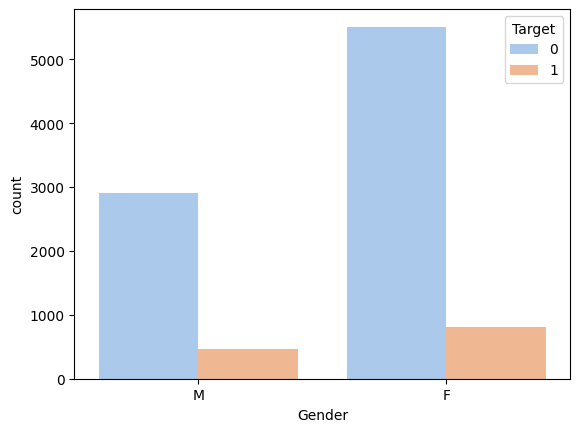

In [80]:
sns.countplot(data=new_df,x="Gender",hue="Target",palette="pastel")

In [81]:
sns.set_context("notebook",font_scale=.7,rc={"grid.linewidth": 0.1,'patch.linewidth': 0.0,
    "axes.grid":True,
    "grid.linestyle": "-",
    "axes.titlesize" : 13,
    "figure.autolayout":True})

palette_1 = ['#46898f','#925094','#00CECB','#80DE99','#C0E680','#FFED66']

sns.set_palette(sns.color_palette(sns.color_palette(palette_1)))

<Figure size 1000x1000 with 0 Axes>

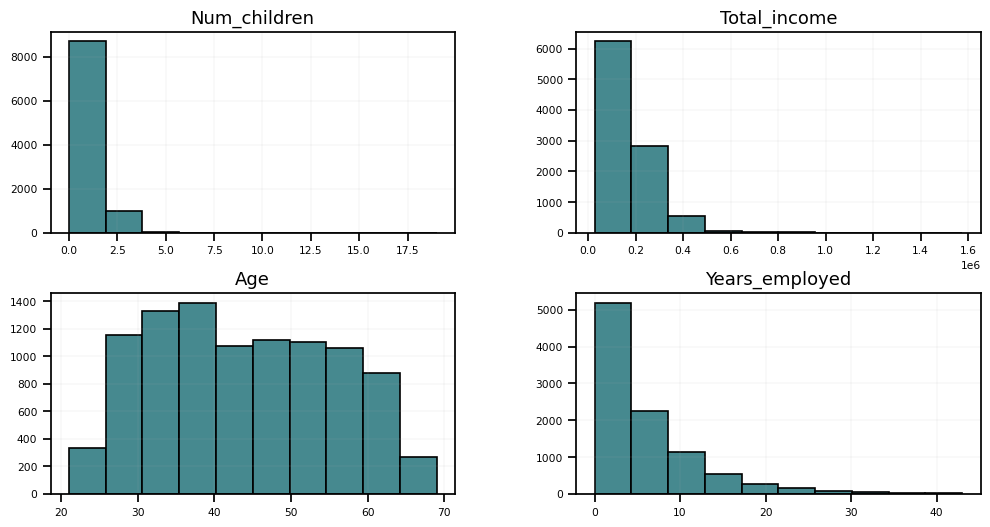

In [82]:
plt.figure(figsize=(10,10))

cols_to_plot = ["Num_children","Total_income","Age","Years_employed"]
new_df[cols_to_plot].hist(edgecolor='black', linewidth=1.2)
fig=plt.gcf()
fig.set_size_inches(12,6)

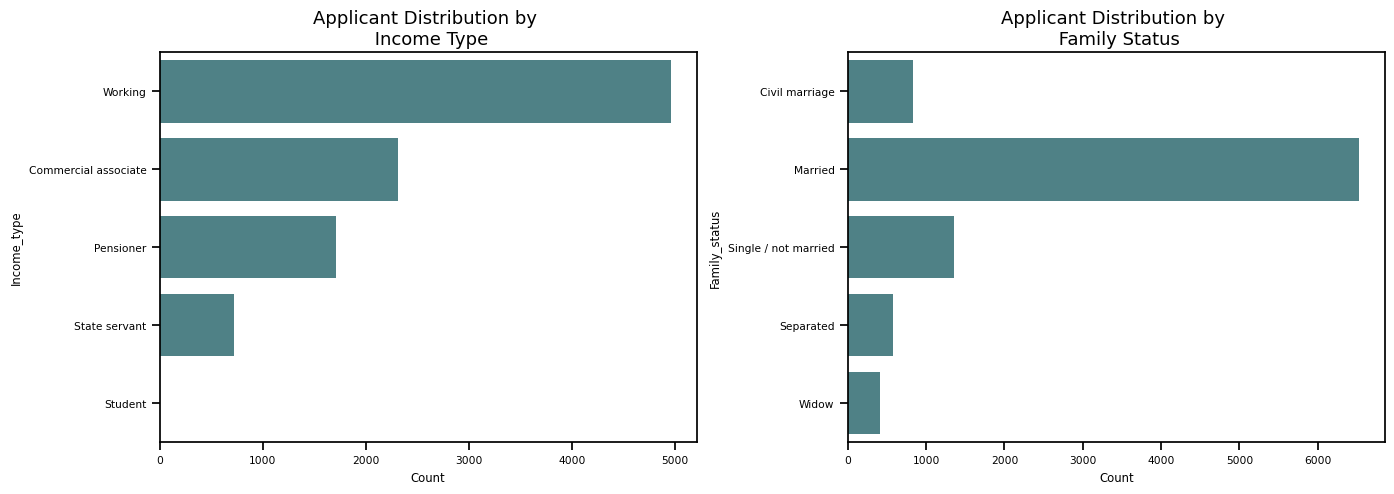

In [83]:
fig, axes = plt.subplots(1,2)

g1=sns.countplot(y=new_df.Income_type,linewidth=1.2, ax=axes[0])
g1.set_title("Applicant Distribution by \n Income Type")
g1.set_xlabel("Count")

g2=sns.countplot(y=new_df.Family_status,linewidth=1.2, ax=axes[1])
g2.set_title("Applicant Distribution by \n Family Status")
g2.set_xlabel("Count")

fig.set_size_inches(14,5)

plt.tight_layout()

plt.show()

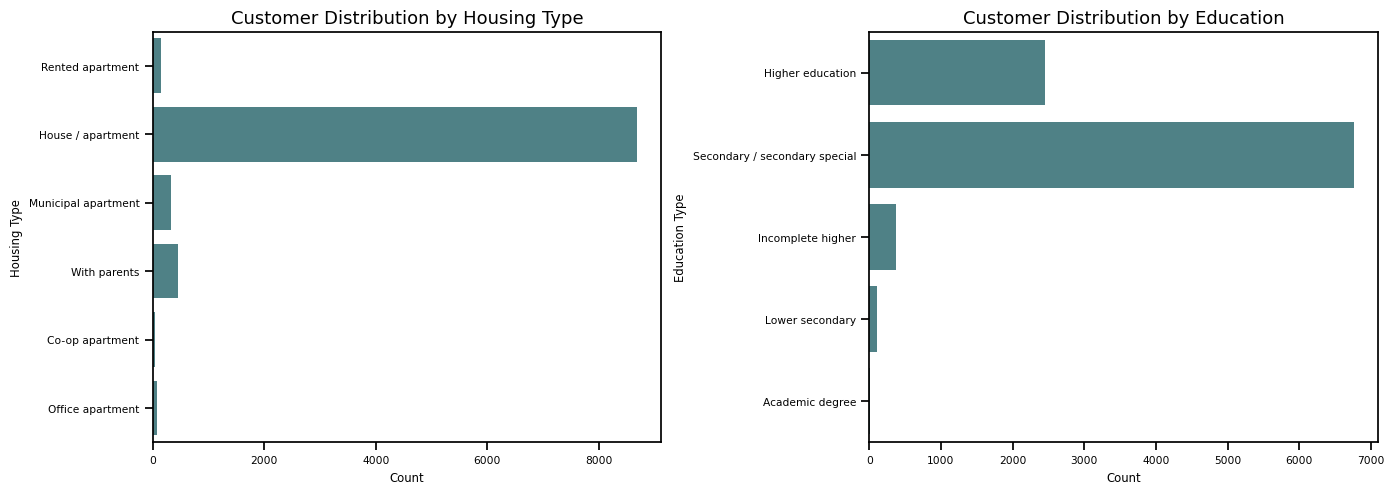

In [84]:
fig, axes = plt.subplots(1,2)

g1= sns.countplot(y=new_df.Housing_type,linewidth=1.2, ax=axes[0])
g1.set_title("Customer Distribution by Housing Type")
g1.set_xlabel("Count")
g1.set_ylabel("Housing Type")

g2= sns.countplot(y=new_df.Education_type, ax=axes[1])
g2.set_title("Customer Distribution by Education")
g2.set_xlabel("Count")
g2.set_ylabel("Education Type")

fig.set_size_inches(14,5)

plt.tight_layout()

plt.show()

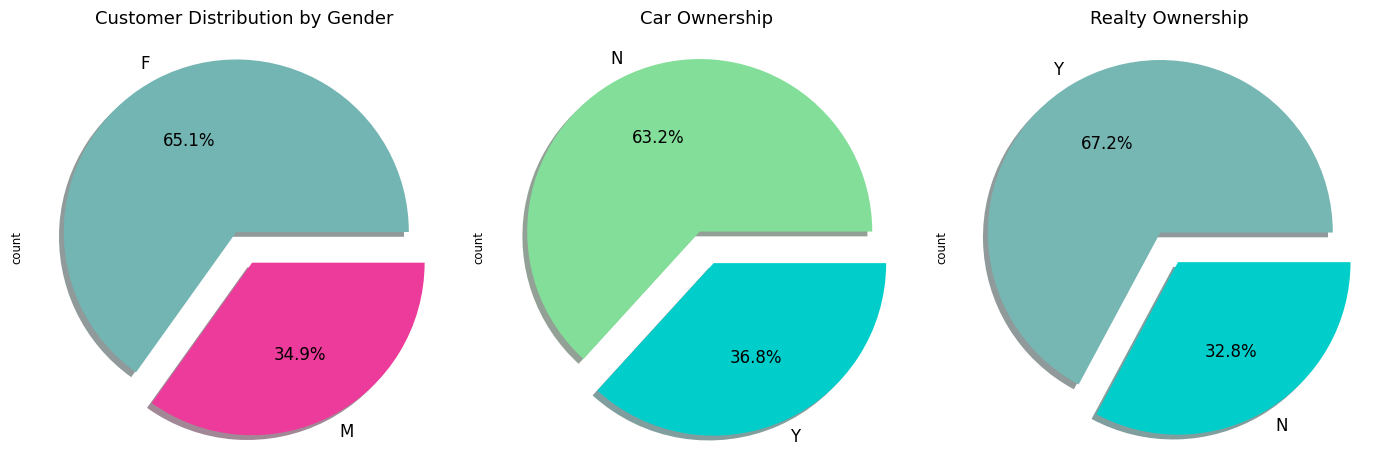

In [85]:
fig, axes = plt.subplots(1,3)

g1= new_df['Gender'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True, colors=["#73B5B3","#EC3B9A"],textprops = {'fontsize':12}, ax=axes[0])
g1.set_title("Customer Distribution by Gender")

g2= new_df['Own_car'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=["#82DE99","#01CECB"],textprops = {'fontsize':12}, ax=axes[1])
g2.set_title("Car Ownership")

g3= new_df['Own_property'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=["#76B6B3","#01CECB"],textprops = {'fontsize':12}, ax=axes[2])
g3.set_title("Realty Ownership")

fig.set_size_inches(14,5)

plt.tight_layout()

plt.show()

In [86]:
new_df.dtypes

,0
ID,int64
Gender,object
Own_car,object
Own_property,object
Num_children,int64
Total_income,float64
Income_type,object
Education_type,object
Family_status,object
Housing_type,object


In [87]:
object_columns = new_df.columns[new_df.dtypes =='str'].tolist()
#object columns in dataset

unique_counts = pd.DataFrame.from_records([(col, new_df[object_columns][col].nunique()) for col in new_df[object_columns].columns],
                          columns=['Column_Name', 'Num_Unique']).sort_values(by=['Num_Unique'])

unique_counts
#unique counts for object columns

,Column_Name,Num_Unique


In [88]:
# Checking unique values from Categorical Columns
for i in new_df.columns[(new_df.dtypes =='str').values].tolist():
    print(i,'\n')
    print(new_df[i].value_counts())
    print('-----------------------------------------------')

In [89]:
# Encode binary features
new_df["Gender"] =  new_df["Gender"].replace(['F','M'],[0,1])
new_df["Own_car"] = new_df["Own_car"].replace(["Y","N"],[1,0])
new_df["Own_property"] = new_df["Own_property"].replace(["Y","N"],[1,0])

In [90]:
new_df.head(2)

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,1,15,33.0,0,12.4
1,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,None,2.0,0,29,59.0,0,3.1


In [91]:
new_df.Income_type.unique()

array(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], dtype=object)

In [92]:
new_df.Family_status.unique()

array(['Civil marriage', 'Married', 'Single / not married', 'Separated',
       'Widow'], dtype=object)

In [93]:
new_df["Is_Working"] = new_df["Income_type"].replace(["Working","Commercial associate","State servant","Pensioner","Student"],
                                            [1,1,1,0,0])

new_df["Marital_status"] = new_df["Family_status"].replace(["Civil marriage","Married","Single / not married","Separated","Widow"],
                                                           [1,1,0,0,0])

In [94]:
new_df

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,1,15,33.0,0,12.4,1,1
1,5008806,1,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,None,2.0,0,29,59.0,0,3.1,1,1
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,None,1.0,0,4,52.0,0,8.4,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,0,20,62.0,1,0.0,0,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,0,5,46.0,0,2.1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,Pensioner,Secondary / secondary special,Civil marriage,Municipal apartment,0,0,0,None,2.0,1,20,56.0,0,0.5,0,1
9705,5149055,0,0,1,0,112500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,1,1,0,None,2.0,1,19,43.0,0,7.4,1,1
9706,5149729,1,1,1,0,90000.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,None,2.0,1,21,52.0,0,4.7,1,1
9707,5149838,0,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,0,1,1,None,2.0,1,32,34.0,0,3.6,0,1


In [95]:
education_type = {'Secondary / secondary special':'Secondary',
                     'Lower secondary':'Secondary',
                     'Higher education':'Higher education',
                     'Incomplete higher':'Higher education',
                     'Academic degree':'Academic degree'}

new_df["Education_type"] = new_df["Education_type"].map(education_type)

In [96]:
new_df.Education_type.value_counts()

,count
Education_type,
Secondary,6875
Higher education,2828
Academic degree,6


In [97]:
new_df

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,1,15,33.0,0,12.4,1,1
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,0,29,59.0,0,3.1,1,1
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,0,1,1,None,1.0,0,4,52.0,0,8.4,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,0,20,62.0,1,0.0,0,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,0,5,46.0,0,2.1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,Pensioner,Secondary,Civil marriage,Municipal apartment,0,0,0,None,2.0,1,20,56.0,0,0.5,0,1
9705,5149055,0,0,1,0,112500.0,Commercial associate,Secondary,Married,House / apartment,1,1,0,None,2.0,1,19,43.0,0,7.4,1,1
9706,5149729,1,1,1,0,90000.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,1,21,52.0,0,4.7,1,1
9707,5149838,0,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,0,1,1,None,2.0,1,32,34.0,0,3.6,0,1


In [98]:
new_df["Household_Size"] = new_df["Num_children"] + new_df["Marital_status"].apply(lambda x: 2 if x==1 else 1)

In [99]:
new_df

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,1,15,33.0,0,12.4,1,1,2
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,0,29,59.0,0,3.1,1,1,2
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,0,1,1,None,1.0,0,4,52.0,0,8.4,1,0,1
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,0,20,62.0,1,0.0,0,0,1
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,0,5,46.0,0,2.1,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,Pensioner,Secondary,Civil marriage,Municipal apartment,0,0,0,None,2.0,1,20,56.0,0,0.5,0,1,2
9705,5149055,0,0,1,0,112500.0,Commercial associate,Secondary,Married,House / apartment,1,1,0,None,2.0,1,19,43.0,0,7.4,1,1,2
9706,5149729,1,1,1,0,90000.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,1,21,52.0,0,4.7,1,1,2
9707,5149838,0,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,0,1,1,None,2.0,1,32,34.0,0,3.6,0,1,2


In [100]:
numerical_cols = ["Total_income","Age","Years_employed","Household_Size"]

fig = make_subplots(rows=2, cols=2, start_cell="bottom-left",
                   subplot_titles=("Income", "Age", "Experience", "Family Members Count"))

fig.add_trace(go.Box(x=new_df.Total_income, name='Income',boxmean=True),row=1,col=1)
fig.add_trace(go.Box(x=new_df.Age, name='Age', boxmean=True), row=1, col=2)
fig.add_trace(go.Box(x=new_df.Years_employed, name='Experience', boxmean=True), row=2, col=1)
fig.add_trace(go.Box(x=new_df.Household_Size, name="Family Member Count", boxmean=True),row=2, col=2)

fig.show()

In [101]:
new_df["Years_employed"].value_counts()

,count
Years_employed,
0.0,1697
0.5,130
0.6,117
0.3,115
0.4,110
...,...
0.1,1
35.9,1
35.1,1


In [102]:
new_df["Household_Size"].value_counts()

,count
Household_Size,
2,5173
1,1957
3,1636
4,801
5,117
6,18
7,4
15,1
20,1


In [103]:
new_df.Years_employed.max()

43.0

In [104]:
new_df[(new_df["Years_employed"]>=40)]

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size
2442,5037026,0,0,1,0,85500.0,Working,Secondary,Separated,House / apartment,0,0,0,None,1.0,0,10,59.0,0,41.3,1,0,1
2686,5041425,0,1,1,0,202500.0,State servant,Higher education,Single / not married,House / apartment,0,1,0,None,1.0,0,4,61.0,0,41.2,1,0,1
3830,5056142,1,1,0,0,157500.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,0,38,64.0,0,40.8,1,1,2
5475,5090311,0,1,1,0,162000.0,State servant,Secondary,Married,House / apartment,0,0,0,None,2.0,0,17,61.0,0,41.7,1,1,2
7142,5112905,0,0,1,0,180000.0,Commercial associate,Secondary,Married,House / apartment,0,0,0,None,2.0,0,16,63.0,0,43.0,1,1,2
7665,5116243,0,0,1,0,315000.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,0,51,61.0,0,40.6,1,1,2
8274,5125725,0,0,1,0,202500.0,Commercial associate,Secondary,Married,House / apartment,0,0,0,None,2.0,1,47,63.0,0,40.5,1,1,2
9328,5148702,0,0,1,0,126000.0,Commercial associate,Secondary,Married,House / apartment,0,0,0,None,2.0,0,57,62.0,0,42.9,1,1,2


In [105]:
new_df[(new_df['Household_Size']>=9)]

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Target,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size
3922,5061207,1,1,1,14,225000.0,Working,Secondary,Separated,House / apartment,0,0,0,None,15.0,0,58,49.0,0,4.6,1,0,15
6840,5105054,0,0,1,19,112500.0,Working,Secondary,Single / not married,House / apartment,1,1,0,None,20.0,0,5,30.0,0,5.1,1,0,20
8094,5118330,0,0,0,7,157500.0,Working,Secondary,Married,House / apartment,1,1,0,None,9.0,1,26,38.0,0,4.5,1,1,9


In [106]:
new_df.drop(new_df[(new_df['Household_Size']>9)].index,axis=0,inplace=True)

In [107]:
new_df["Household_Size"].value_counts()

,count
Household_Size,
2,5173
1,1957
3,1636
4,801
5,117
6,18
7,4
9,1


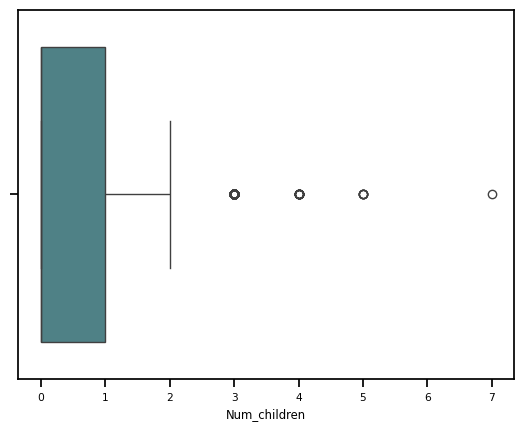

In [108]:
sns.boxplot(x=new_df['Num_children']);

In [109]:
new_df['Num_children'].value_counts()

,count
Num_children,
0,6819
1,1886
2,852
3,126
4,18
5,5
7,1


In [110]:
new_df.columns

Index(['ID', 'Gender', 'Own_car', 'Own_property', 'Num_children',
       'Total_income', 'Income_type', 'Education_type', 'Family_status',
       'Housing_type', 'Work_phone', 'Phone', 'Email', 'Occupation_type',
       'Num_family', 'Target', 'Account_length', 'Age', 'Unemployed',
       'Years_employed', 'Is_Working', 'Marital_status', 'Household_Size'],
      dtype='object')

In [111]:
new_df = new_df.loc[:,['ID', 'Gender', 'Own_car', 'Own_property', 'Num_children',
       'Total_income', 'Income_type', 'Education_type', 'Family_status',
       'Housing_type', 'Work_phone', 'Phone', 'Email', 'Occupation_type',
       'Num_family', 'Account_length', 'Age', 'Unemployed',
       'Years_employed', 'Is_Working', 'Marital_status', 'Household_Size','Target']]

In [112]:
new_df.head()

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size,Target
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,15,33.0,0,12.4,1,1,2,1
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,29,59.0,0,3.1,1,1,2,0
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,0,1,1,None,1.0,4,52.0,0,8.4,1,0,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,20,62.0,1,0.0,0,0,1,0
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,5,46.0,0,2.1,1,1,2,0


In [113]:
new_df[(new_df["Income_type"]=="Pensioner")]["Target"].value_counts()

,count
Target,
0,1503
1,209


In [114]:
new_df.loc[(new_df["Income_type"]=="Pensioner") & (new_df["Target"]==0),"Target"] = 1

In [115]:
new_df[(new_df["Income_type"]=="Pensioner")]["Target"].value_counts()

,count
Target,
1,1712


In [116]:
new_df.loc[new_df["Income_type"]=="Student","Is_Working"] = 1

In [117]:
new_df.loc[new_df["Income_type"]=="Student"]

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size,Target
280,5010456,0,0,1,0,171000.0,Student,Higher education,Married,House / apartment,0,0,1,None,2.0,39,51.0,0,10.7,1,1,2,0
1202,5025088,1,0,0,0,135000.0,Student,Higher education,Single / not married,With parents,0,0,1,None,1.0,14,25.0,0,1.6,1,0,1,1
3143,5047796,0,0,1,1,112500.0,Student,Secondary,Civil marriage,House / apartment,0,0,0,None,3.0,12,33.0,0,2.2,1,1,3,0


In [118]:
new_df

,ID,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Family_status,Housing_type,Work_phone,Phone,Email,Occupation_type,Num_family,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size,Target
0,5008804,1,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,None,2.0,15,33.0,0,12.4,1,1,2,1
1,5008806,1,1,1,0,112500.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,29,59.0,0,3.1,1,1,2,0
2,5008808,0,0,1,0,270000.0,Commercial associate,Secondary,Single / not married,House / apartment,0,1,1,None,1.0,4,52.0,0,8.4,1,0,1,0
3,5008812,0,0,1,0,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,None,1.0,20,62.0,1,0.0,0,0,1,1
4,5008815,1,1,1,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,None,2.0,5,46.0,0,2.1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,5148694,0,0,0,0,180000.0,Pensioner,Secondary,Civil marriage,Municipal apartment,0,0,0,None,2.0,20,56.0,0,0.5,0,1,2,1
9705,5149055,0,0,1,0,112500.0,Commercial associate,Secondary,Married,House / apartment,1,1,0,None,2.0,19,43.0,0,7.4,1,1,2,1
9706,5149729,1,1,1,0,90000.0,Working,Secondary,Married,House / apartment,0,0,0,None,2.0,21,52.0,0,4.7,1,1,2,1
9707,5149838,0,0,1,0,157500.0,Pensioner,Higher education,Married,House / apartment,0,1,1,None,2.0,32,34.0,0,3.6,0,1,2,1


In [119]:
new_df.drop(["ID"],axis=1,inplace=True)

In [120]:
new_df.drop(["Email"],axis=1,inplace=True)

In [121]:
new_df.drop(["Phone"],axis=1,inplace=True)

In [122]:
new_df.drop(["Work_phone"],axis=1,inplace=True)

In [123]:
new_df.drop(["Housing_type"],axis=1,inplace=True)

In [124]:
new_df.drop(["Family_status"],axis=1,inplace=True)

In [125]:
new_df

,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Occupation_type,Num_family,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size,Target
0,1,1,1,0,427500.0,Working,Higher education,None,2.0,15,33.0,0,12.4,1,1,2,1
1,1,1,1,0,112500.0,Working,Secondary,None,2.0,29,59.0,0,3.1,1,1,2,0
2,0,0,1,0,270000.0,Commercial associate,Secondary,None,1.0,4,52.0,0,8.4,1,0,1,0
3,0,0,1,0,283500.0,Pensioner,Higher education,None,1.0,20,62.0,1,0.0,0,0,1,1
4,1,1,1,0,270000.0,Working,Higher education,None,2.0,5,46.0,0,2.1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,0,0,0,0,180000.0,Pensioner,Secondary,None,2.0,20,56.0,0,0.5,0,1,2,1
9705,0,0,1,0,112500.0,Commercial associate,Secondary,None,2.0,19,43.0,0,7.4,1,1,2,1
9706,1,1,1,0,90000.0,Working,Secondary,None,2.0,21,52.0,0,4.7,1,1,2,1
9707,0,0,1,0,157500.0,Pensioner,Higher education,None,2.0,32,34.0,0,3.6,0,1,2,1


In [126]:
new_df.shape

(9707, 17)

In [127]:
new_df.head()

,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Education_type,Occupation_type,Num_family,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size,Target
0,1,1,1,0,427500.0,Working,Higher education,None,2.0,15,33.0,0,12.4,1,1,2,1
1,1,1,1,0,112500.0,Working,Secondary,None,2.0,29,59.0,0,3.1,1,1,2,0
2,0,0,1,0,270000.0,Commercial associate,Secondary,None,1.0,4,52.0,0,8.4,1,0,1,0
3,0,0,1,0,283500.0,Pensioner,Higher education,None,1.0,20,62.0,1,0.0,0,0,1,1
4,1,1,1,0,270000.0,Working,Higher education,None,2.0,5,46.0,0,2.1,1,1,2,0


In [128]:
new_df.drop("Education_type",axis=1,inplace=True)

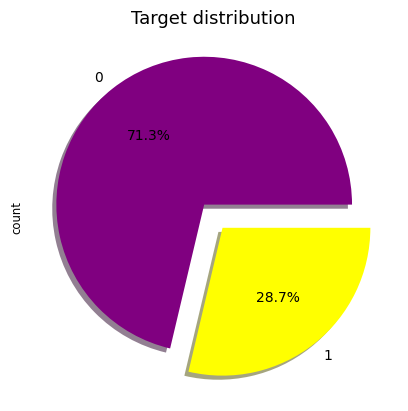

In [129]:
new_df['Target'].value_counts().plot.pie(explode=[0.1,0.1],autopct='%1.1f%%',shadow=True,colors=['purple', 'yellow'],textprops = {'fontsize':10}).set_title("Target distribution")

plt.show()

In [130]:
colname=[]
for x in new_df.columns:
    if new_df[x].dtype=='str':
        colname.append(x)
colname

[]

In [131]:
#To check if there are any special characters in place of values
for i in new_df.columns:
    print({i:new_df[i].unique()})

{'Gender': array([1, 0])}
{'Own_car': array([1, 0])}
{'Own_property': array([1, 0])}
{'Num_children': array([0, 1, 3, 2, 4, 5, 7])}
{'Total_income': array([ 427500. ,  112500. ,  270000. ,  283500. ,  135000. ,  130500. ,
        157500. ,  405000. ,  211500. ,  360000. ,  126000. ,  315000. ,
        247500. ,  297000. ,  225000. ,  166500. ,  216000. ,  255150. ,
        148500. ,  202500. ,   94500. ,  450000. ,  180000. ,   90000. ,
        765000. ,  382500. ,  144000. ,  229500. ,  292500. ,   74250. ,
         40500. ,  337500. ,  193500. ,  267750. ,  139500. ,   67500. ,
        252000. ,  900000. ,  115290. ,  279000. ,   76500. ,  234000. ,
         81000. ,  108000. ,   99000. ,  198000. ,   45000. ,  238500. ,
        117000. ,  153000. , 1350000. ,  445500. ,  495000. ,   85500. ,
        306000. ,  562500. ,  189000. ,  328500. ,  310500. ,  540000. ,
        171000. ,  675000. ,  121500. ,   72000. ,   65250. ,  184500. ,
        103500. ,  162000. ,  165150. ,   54000.

#### **Converting all Non-Numerical Columns to Numerical**


In [132]:
#Converting the categorical data into numerical data
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

for x in colname:
    new_df[x]=le.fit_transform(new_df[x])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print('Feature', x)
    print('mapping', le_name_mapping)

In [133]:
new_df['Income_type']=le.fit_transform(new_df['Income_type'])

In [134]:
new_df

,Gender,Own_car,Own_property,Num_children,Total_income,Income_type,Occupation_type,Num_family,Account_length,Age,Unemployed,Years_employed,Is_Working,Marital_status,Household_Size,Target
0,1,1,1,0,427500.0,4,None,2.0,15,33.0,0,12.4,1,1,2,1
1,1,1,1,0,112500.0,4,None,2.0,29,59.0,0,3.1,1,1,2,0
2,0,0,1,0,270000.0,0,None,1.0,4,52.0,0,8.4,1,0,1,0
3,0,0,1,0,283500.0,1,None,1.0,20,62.0,1,0.0,0,0,1,1
4,1,1,1,0,270000.0,4,None,2.0,5,46.0,0,2.1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,0,0,0,0,180000.0,1,None,2.0,20,56.0,0,0.5,0,1,2,1
9705,0,0,1,0,112500.0,0,None,2.0,19,43.0,0,7.4,1,1,2,1
9706,1,1,1,0,90000.0,4,None,2.0,21,52.0,0,4.7,1,1,2,1
9707,0,0,1,0,157500.0,1,None,2.0,32,34.0,0,3.6,0,1,2,1


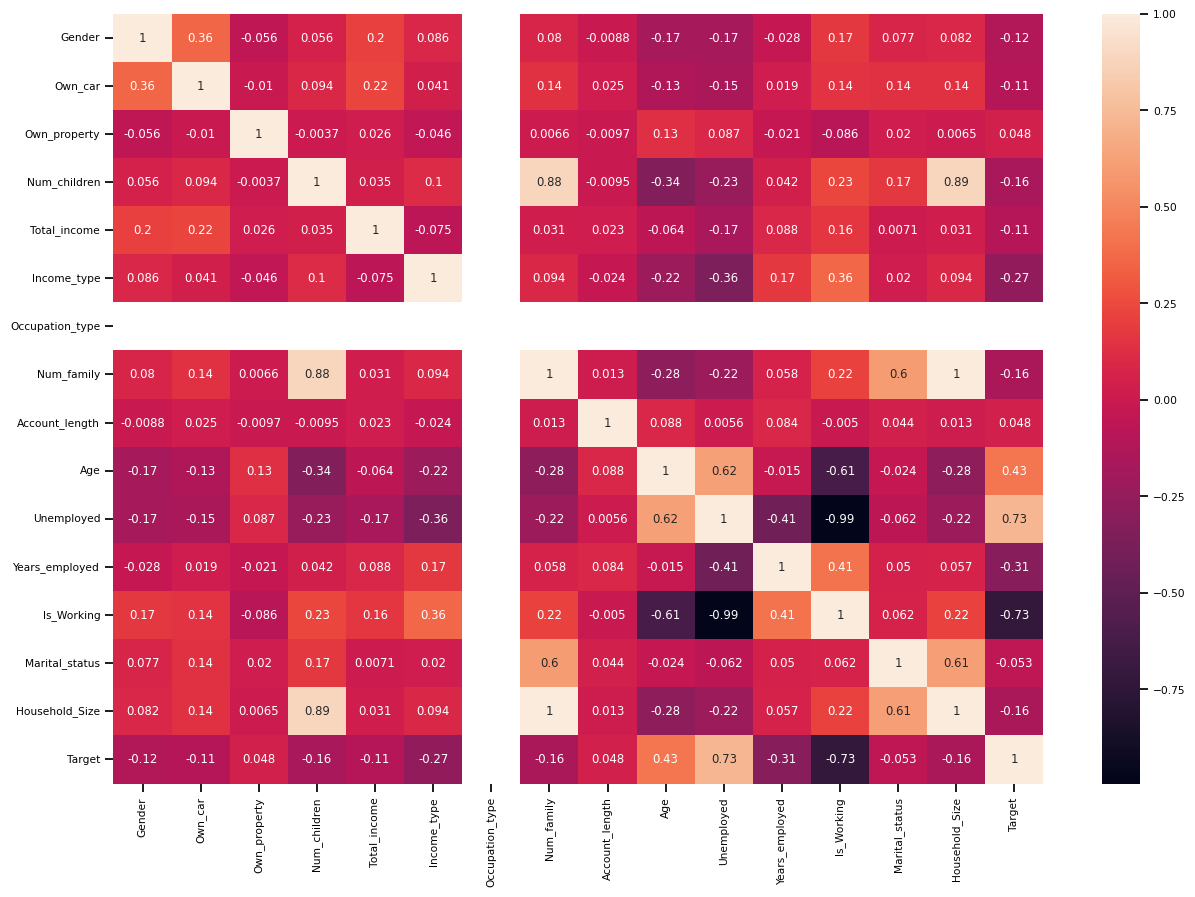

In [135]:
plt.figure(figsize=(15, 10))
corr=new_df.corr()
sns.heatmap(corr,annot=True)
plt.show();

In [136]:
new_df.drop('Occupation_type', axis=1, inplace=True)

In [137]:
new_df.drop('Num_children', axis=1, inplace=True)

In [138]:
new_df.drop("Unemployed",axis=1,inplace=True)

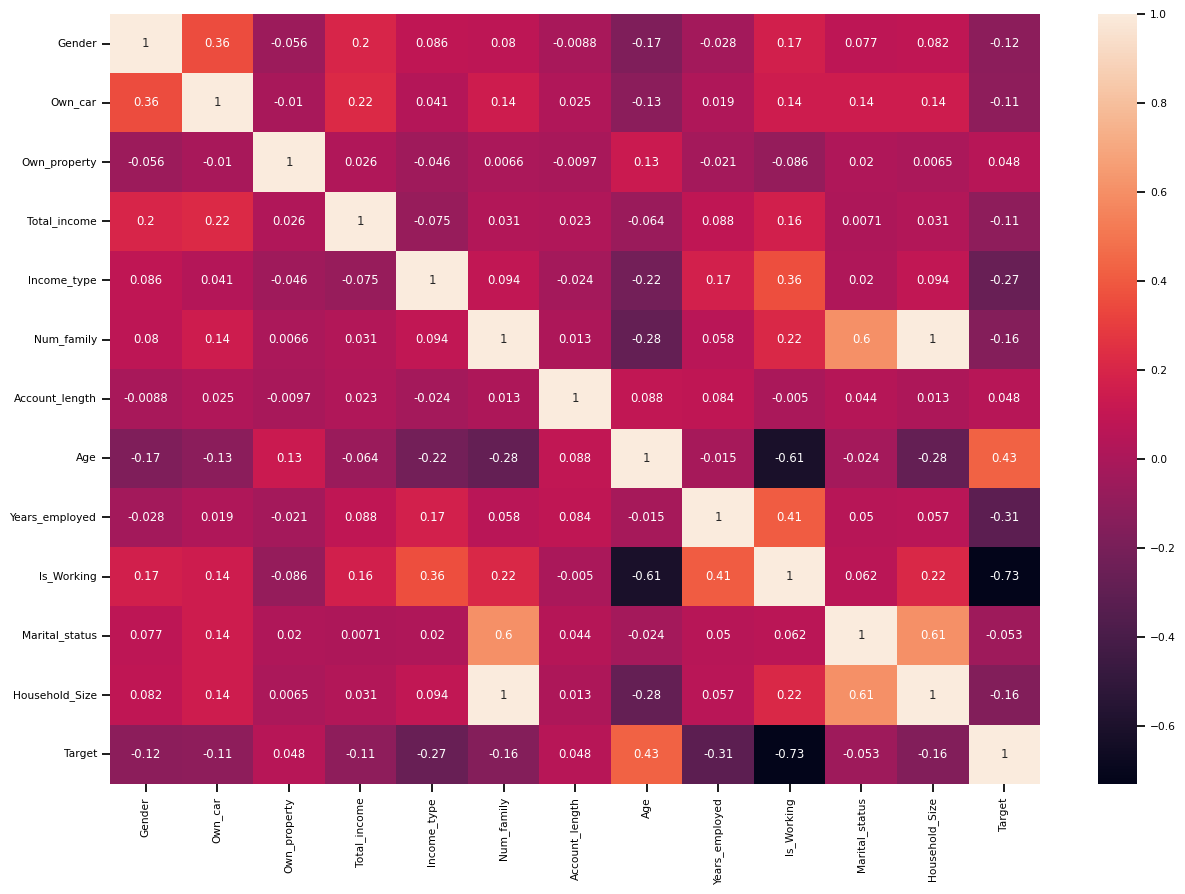

In [139]:
plt.figure(figsize=(15, 10))
corr=new_df.corr()
sns.heatmap(corr,annot=True)
plt.show();

In [140]:
new_df.shape

(9707, 13)

In [141]:
new_df

,Gender,Own_car,Own_property,Total_income,Income_type,Num_family,Account_length,Age,Years_employed,Is_Working,Marital_status,Household_Size,Target
0,1,1,1,427500.0,4,2.0,15,33.0,12.4,1,1,2,1
1,1,1,1,112500.0,4,2.0,29,59.0,3.1,1,1,2,0
2,0,0,1,270000.0,0,1.0,4,52.0,8.4,1,0,1,0
3,0,0,1,283500.0,1,1.0,20,62.0,0.0,0,0,1,1
4,1,1,1,270000.0,4,2.0,5,46.0,2.1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9704,0,0,0,180000.0,1,2.0,20,56.0,0.5,0,1,2,1
9705,0,0,1,112500.0,0,2.0,19,43.0,7.4,1,1,2,1
9706,1,1,1,90000.0,4,2.0,21,52.0,4.7,1,1,2,1
9707,0,0,1,157500.0,1,2.0,32,34.0,3.6,0,1,2,1


In [142]:
new_df.dtypes

,0
Gender,int64
Own_car,int64
Own_property,int64
Total_income,float64
Income_type,int64
Num_family,float64
Account_length,int64
Age,float64
Years_employed,float64
Is_Working,int64


In [143]:
colname=[]
for x in new_df.columns:
    if new_df[x].dtype=='object':
        colname.append(x)
colname

[]

In [144]:
new_df["Gender"] = new_df["Gender"].astype("int")
new_df['Own_car'] = new_df['Own_car'].astype("int")
new_df['Own_property'] = new_df['Own_property'].astype("int")
new_df['Is_Working'] = new_df['Is_Working'].astype("int")
new_df['Marital_status'] = new_df['Marital_status'].astype("int")

In [145]:
new_df.dtypes

,0
Gender,int64
Own_car,int64
Own_property,int64
Total_income,float64
Income_type,int64
Num_family,float64
Account_length,int64
Age,float64
Years_employed,float64
Is_Working,int64


### **Creating X & Y variables for predictions**

In [146]:
#Create X & Y
X = new_df.iloc[:,0:-1]
Y = new_df.iloc[:,-1]

In [147]:
print(X.shape)
print(Y.shape)

(9707, 12)
(9707,)


### **Scaling the X variables**
As there are different feature variables in X, it can have a possibility of giving more importance to the variables having greater range and give less important to variables having small range which is not suitable.  

So to overcome this problem scaling is done on the all variables in X, as it will bring all the variables in a same range

In [148]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

scaler.fit(X)
X = scaler.transform(X)

In [149]:
from sklearn.model_selection import train_test_split
#<1000=in range of 80-20  &  >1000=in range of 70-30

#Split the data into test and train
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=10)


In [150]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(7765, 12)
(7765,)
(1942, 12)
(1942,)


#### Logistic Regression:

In [151]:
from sklearn.linear_model import LogisticRegression
#create a model object
classifier = LogisticRegression()

#train the model object
classifier.fit(X_train,Y_train)

Y_pred=classifier.predict(X_test)

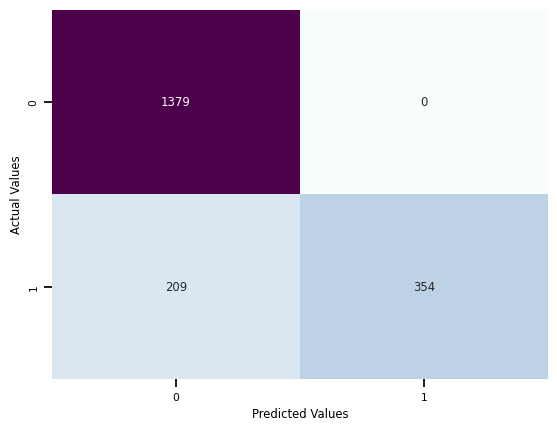

Classification report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1379
           1       1.00      0.63      0.77       563

    accuracy                           0.89      1942
   macro avg       0.93      0.81      0.85      1942
weighted avg       0.91      0.89      0.88      1942

Accuracy of the model:  0.892378990731205


In [152]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [153]:
classifier.score(X_train,Y_train)

0.8886027044430135

### KNN

In [154]:
#predicting using the KNeighbors_Classifier
from sklearn.neighbors import KNeighborsClassifier
model_KNN=KNeighborsClassifier(n_neighbors=13,
                              metric='manhattan')

#euclidean,manhattan,minkowski
#fit the model on the data and predict the values
model_KNN.fit(X_train,Y_train)

Y_pred=model_KNN.predict(X_test)

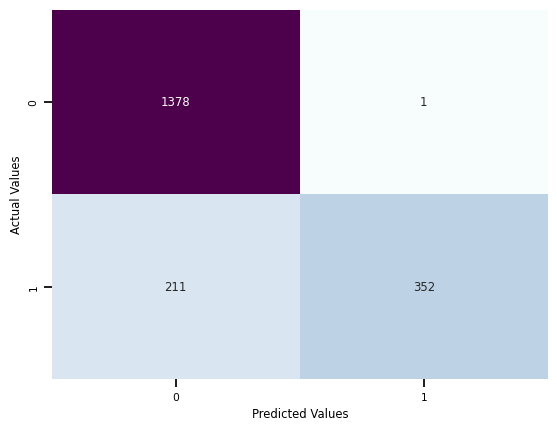

Classification report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1379
           1       1.00      0.63      0.77       563

    accuracy                           0.89      1942
   macro avg       0.93      0.81      0.85      1942
weighted avg       0.90      0.89      0.88      1942

Accuracy of the model:  0.8908341915550978


In [155]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()


print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [156]:
model_KNN.score(X_train,Y_train)

0.8882163554410818

In [157]:
#predicting using the Decision Tree_Classifier
from sklearn.tree import DecisionTreeClassifier

model_DecisionTree=DecisionTreeClassifier(criterion="gini",
                                          max_depth=None,random_state=10)


#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)
Y_pred=model_DecisionTree.predict(X_test)

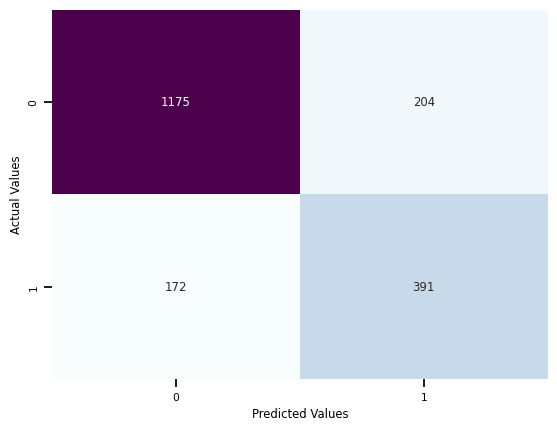

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1379
           1       0.66      0.69      0.68       563

    accuracy                           0.81      1942
   macro avg       0.76      0.77      0.77      1942
weighted avg       0.81      0.81      0.81      1942

Accuracy of the model:  0.8063851699279093


In [158]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [159]:
model_DecisionTree.score(X_train,Y_train)

1.0

In [160]:
?model_RandomForest

Object `model_RandomForest` not found.


In [161]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier

model_RandomForest=RandomForestClassifier(n_estimators=85,random_state=10,max_depth=15)


#fit the model on the data and predict the values
model_RandomForest.fit(X_train,Y_train)

Y_pred=model_RandomForest.predict(X_test)

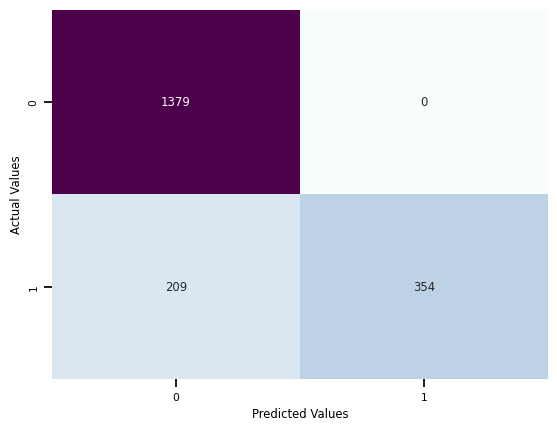

Classification report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1379
           1       1.00      0.63      0.77       563

    accuracy                           0.89      1942
   macro avg       0.93      0.81      0.85      1942
weighted avg       0.91      0.89      0.88      1942

Accuracy of the model:  0.892378990731205


In [162]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [163]:
model_RandomForest.score(X_train,Y_train)

0.9173213135866065

In [164]:
y=new_df["Target"]
x=new_df.drop(["Target"],axis=1)

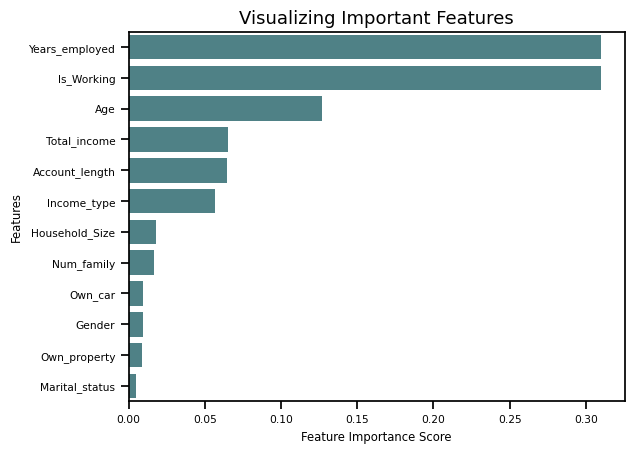

In [165]:
feature_imp = pd.Series(model_RandomForest.feature_importances_,index=x.columns.tolist()).sort_values(ascending=False)
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Visualizing Important Features")
plt.legend()
plt.show()

In [166]:
new_df.drop(["Household_Size"],axis=1,inplace=True)

In [167]:
new_df.drop(["Own_car"],axis=1,inplace=True)

In [168]:
new_df.drop(["Own_property"],axis=1,inplace=True)

In [169]:
new_df.drop(["Marital_status"],axis=1,inplace=True)

In [170]:
new_df.shape

(9707, 9)

In [171]:
#Create X & Y
X = new_df.iloc[:,0:-1]
Y = new_df.iloc[:,-1]

In [172]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaler.fit(X)
X = scaler.transform(X)


In [173]:
from sklearn.model_selection import train_test_split
#<1000=in range of 80-20  &  >1000=in range of 70-30

#Split the data into test and train
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=10)


In [174]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier

model_RandomForest=RandomForestClassifier(n_estimators=85,random_state=10,
                                          max_depth=15,min_samples_split=5)


#fit the model on the data and predict the values
model_RandomForest.fit(X_train,Y_train)

Y_pred=model_RandomForest.predict(X_test)

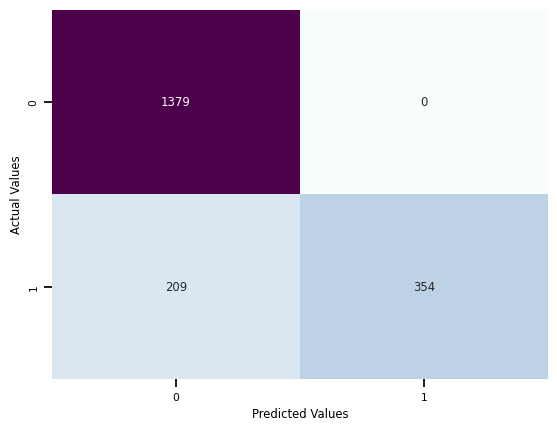

Classification report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1379
           1       1.00      0.63      0.77       563

    accuracy                           0.89      1942
   macro avg       0.93      0.81      0.85      1942
weighted avg       0.91      0.89      0.88      1942

Accuracy of the model:  0.892378990731205


In [175]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)


In [176]:
?ExtraTreesClassifier

Object `ExtraTreesClassifier` not found.


In [177]:
from sklearn.ensemble import ExtraTreesClassifier

model_ExtraTrees = ExtraTreesClassifier(n_estimators=90,random_state=42)

#fit the model on the data and predict the values
model_ExtraTrees.fit(X_train,Y_train)

Y_pred = model_ExtraTrees.predict(X_test)

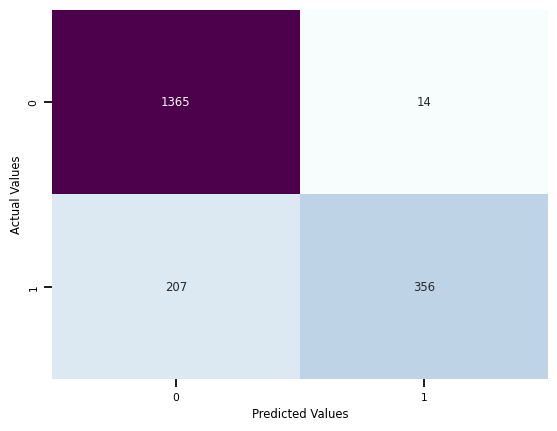

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      1379
           1       0.96      0.63      0.76       563

    accuracy                           0.89      1942
   macro avg       0.92      0.81      0.84      1942
weighted avg       0.90      0.89      0.88      1942

Accuracy of the model:  0.8861997940267765


In [178]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)


In [179]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model_AdaBoost = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=10),
                                    n_estimators=250,
                                    random_state=10)

# Fit the model on the data and predict the values
model_AdaBoost.fit(X_train, Y_train)
Y_pred = model_AdaBoost.predict(X_test)

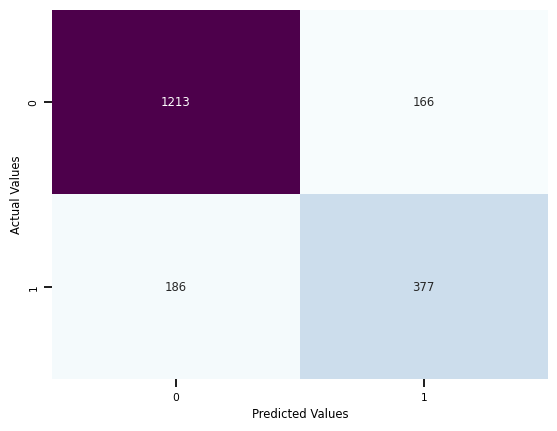

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      1379
           1       0.69      0.67      0.68       563

    accuracy                           0.82      1942
   macro avg       0.78      0.77      0.78      1942
weighted avg       0.82      0.82      0.82      1942

Accuracy of the model:  0.8187435633367662


In [180]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [181]:
!pip install xgboost

In [182]:
?XGBClassifier

Object `XGBClassifier` not found.


In [183]:
from xgboost import XGBClassifier
model_XGBoost=XGBClassifier(n_estimators=150,learning_rate=0.6,booster="gbtree",max_depth=30,
                              random_state=10)

#fit the model on the data and predict the values
model_XGBoost.fit(X_train,Y_train)

Y_pred=model_XGBoost.predict(X_test)

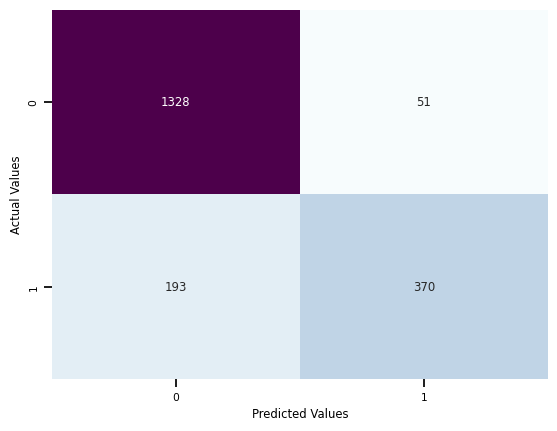

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1379
           1       0.88      0.66      0.75       563

    accuracy                           0.87      1942
   macro avg       0.88      0.81      0.83      1942
weighted avg       0.87      0.87      0.87      1942

Accuracy of the model:  0.874356333676622


In [184]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

<Axes: xlabel='Target'>

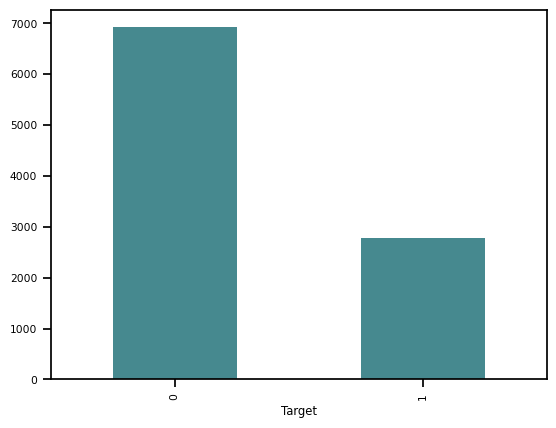

In [185]:
new_df.Target.value_counts().plot(kind="bar")

### **SMOTE**

In [186]:
!pip install imblearn

In [187]:
import sklearn.utils._param_validation

In [188]:
#!pip uninstall scikit-learn --yes
#!pip uninstall imblearn --yes
#!pip install scikit-learn==1.2.2
#!pip install imblearn

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: imblearn 0.0
Uninstalling imblearn-0.0:
  Successfully uninstalled imblearn-0.0
  Using cached scikit-learn-1.2.2.tar.gz (7.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Operation cancelled by user
  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)


In [189]:
#pip install --upgrade scikit-learn imbalanced-learn

In [190]:
import imblearn

In [217]:
X=new_df.values[:,:-1]
Y=new_df.values[:,-1]

In [220]:
new_df.columns

Index(['Gender', 'Total_income', 'Income_type', 'Num_family', 'Account_length',
       'Age', 'Years_employed', 'Is_Working', 'Target'],
      dtype='object')

In [219]:
import pickle
from sklearn.preprocessing import StandardScaler

# 1. Grab the 6 features directly from new_df (which is still a DataFrame)
top_6_features = [
    'Total_income',
    'Income_type',
    'Occupation_type',
    'Account_length',
    'Age',
    'Years_employed'
]

X_filtered = new_df[top_6_features]

# 2. Create and fit a NEW scaler on just these 6 features
scaler_6 = StandardScaler()
scaler_6.fit(X_filtered)

# 3. Export this new 6-feature scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler_6, f)

KeyError: "['Occupation_type'] not in index"

In [192]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(X)
X=scaler.transform(X)

In [214]:
import joblib
import pickle
scale
# Assuming your scaler variable is named 'scaler'
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [194]:
from sklearn.model_selection import train_test_split

#split the data into test and train
X_train, X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=10)


In [195]:
print("Before OverSampling, counts of label '1': ", (sum(Y_train == 1)))
print("Before OverSampling, counts of label '0': ", (sum(Y_train == 0)))

# import SMOTE from imblearn library
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 10)
X_train_res, Y_train_res = sm.fit_resample(X_train, Y_train)

print('After OverSampling, the shape of train_X: ', (X_train_res.shape))
print('After OverSampling, the shape of train_y: ', (Y_train_res.shape))

print("After OverSampling, counts of label '1': ", (sum(Y_train_res == 1)))
print("After OverSampling, counts of label '0': ", (sum(Y_train_res == 0)))

Before OverSampling, counts of label '1':  2223
Before OverSampling, counts of label '0':  5542
After OverSampling, the shape of train_X:  (11084, 8)
After OverSampling, the shape of train_y:  (11084,)
After OverSampling, counts of label '1':  5542
After OverSampling, counts of label '0':  5542


In [196]:
#predicting using the Random_Forest_Classifier
from sklearn.ensemble import RandomForestClassifier

model_RandomForest=RandomForestClassifier(n_estimators=125,random_state=10)


#fit the model on the data and predict the values
model_RandomForest.fit(X_train_res,Y_train_res)

Y_pred=model_RandomForest.predict(X_test)

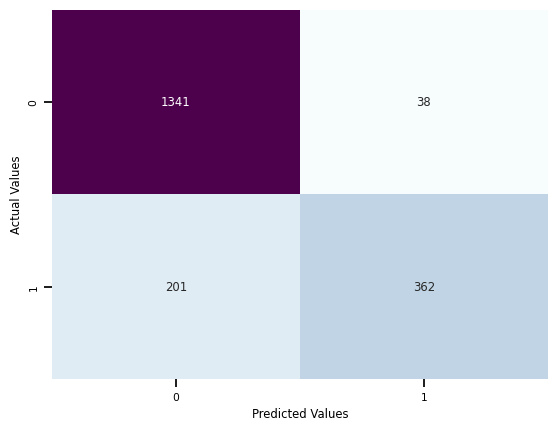

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92      1379
         1.0       0.91      0.64      0.75       563

    accuracy                           0.88      1942
   macro avg       0.89      0.81      0.83      1942
weighted avg       0.88      0.88      0.87      1942

Accuracy of the model:  0.8769309989701339


In [197]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)


In [198]:
#predicting using the Extra_Trees_Classifier
from sklearn.ensemble import ExtraTreesClassifier

model_ExtraTrees = ExtraTreesClassifier(n_estimators=110,random_state=10)

#fit the model on the data and predict the values
model_ExtraTrees.fit(X_train_res,Y_train_res)

Y_pred = model_ExtraTrees.predict(X_test)

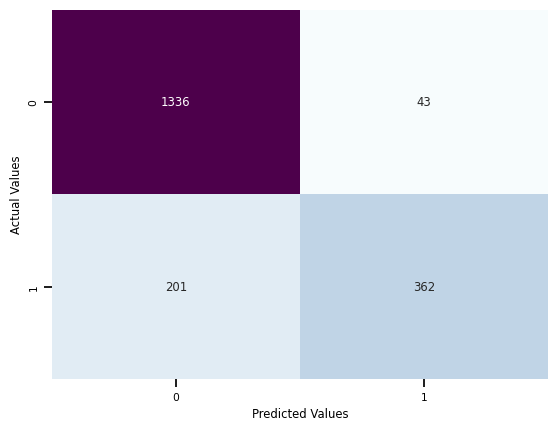

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92      1379
         1.0       0.89      0.64      0.75       563

    accuracy                           0.87      1942
   macro avg       0.88      0.81      0.83      1942
weighted avg       0.88      0.87      0.87      1942

Accuracy of the model:  0.874356333676622


In [199]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [200]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

model_AdaBoost = AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=10),
                                    n_estimators=50,
                                    random_state=10)

# Fit the model on the data and predict the values
model_AdaBoost.fit(X_train_res, Y_train_res)
Y_pred = model_AdaBoost.predict(X_test)

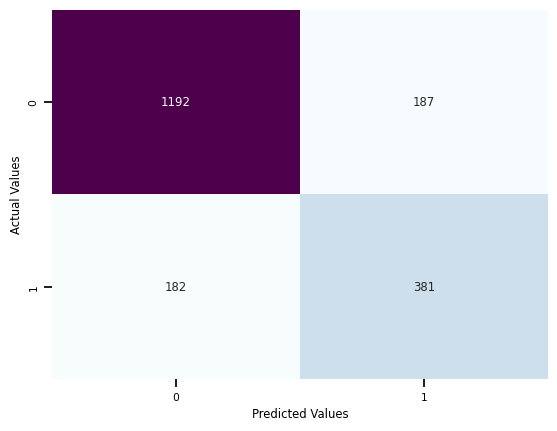

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.87      1379
         1.0       0.67      0.68      0.67       563

    accuracy                           0.81      1942
   macro avg       0.77      0.77      0.77      1942
weighted avg       0.81      0.81      0.81      1942

Accuracy of the model:  0.809989701338826


In [201]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [202]:
from xgboost import XGBClassifier
model_XGBoost=XGBClassifier(n_estimators=100,
                              random_state=10)

#fit the model on the data and predict the values
model_XGBoost.fit(X_train_res,Y_train_res)

Y_pred=model_XGBoost.predict(X_test)

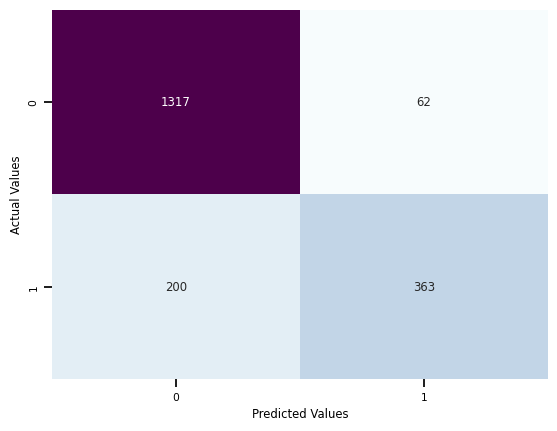

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91      1379
         1.0       0.85      0.64      0.73       563

    accuracy                           0.87      1942
   macro avg       0.86      0.80      0.82      1942
weighted avg       0.86      0.87      0.86      1942

Accuracy of the model:  0.8650875386199794


In [203]:
##### from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [204]:
from sklearn.linear_model import LogisticRegression
#create a model object
classifier = LogisticRegression()

#train the model object
classifier.fit(X_train_res,Y_train_res)

Y_pred=classifier.predict(X_test)

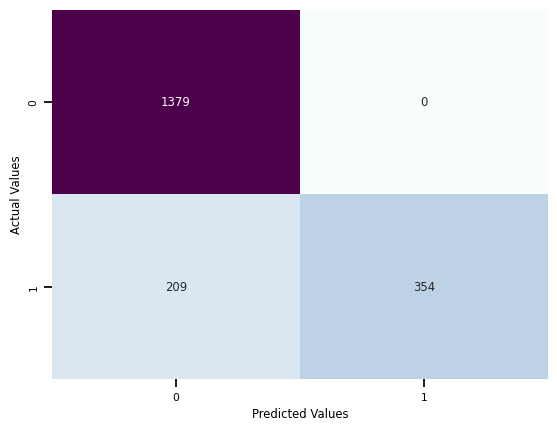

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93      1379
         1.0       1.00      0.63      0.77       563

    accuracy                           0.89      1942
   macro avg       0.93      0.81      0.85      1942
weighted avg       0.91      0.89      0.88      1942

Accuracy of the model:  0.892378990731205


In [205]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [206]:
#predicting using the KNeighbors_Classifier
from sklearn.neighbors import KNeighborsClassifier
model_KNN=KNeighborsClassifier(n_neighbors=15,
                              metric='euclidean')

#euclidean,manhattan,minkowski
#fit the model on the data and predict the values
model_KNN.fit(X_train_res,Y_train_res)

Y_pred=model_KNN.predict(X_test)

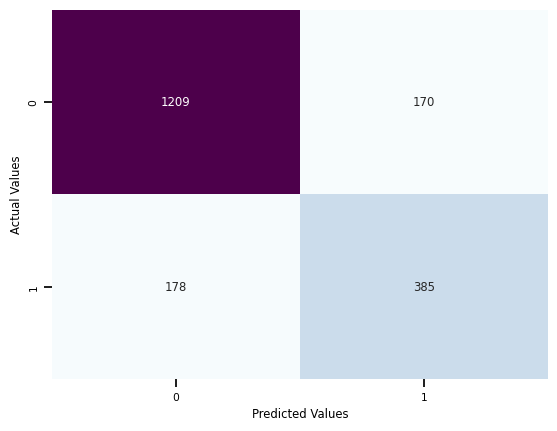

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      0.88      0.87      1379
         1.0       0.69      0.68      0.69       563

    accuracy                           0.82      1942
   macro avg       0.78      0.78      0.78      1942
weighted avg       0.82      0.82      0.82      1942

Accuracy of the model:  0.8208032955715757


In [207]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [222]:
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. Define X and Y (X will have the 8 features)
X = new_df.drop(['Target'], axis=1)
y = new_df['Target']

# 2. Fit and save the 8-feature Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Train and save your AdaBoost Model on those exact same 8 scaled features
# (Assuming you already did your train_test_split and SMOTE here if needed)
final_model_AdaBoost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=10),
    n_estimators=best_n_estimators,
    random_state=10
)
final_model_AdaBoost.fit(X_train_res, Y_train_res) # Or fit on X_train_res if using SMOTE

with open('model.pkl', 'wb') as f:
    pickle.dump(model_AdaBoost, f)

In [223]:
import sklearn
print(sklearn.__version__)

1.8.0


In [208]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# Define the initial model with the maximum number of estimators
initial_n_estimators = 200
model_AdaBoost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=10),
    n_estimators=initial_n_estimators,
    random_state=10
)

# Split your training data into training and validation sets
#X_train_sub, X_val, Y_train_sub, Y_val = train_test_split(X_train_res, Y_train_res, test_size=0.2, random_state=42)

# Fit the initial model on the training subset
model_AdaBoost.fit(X_train_res, Y_train_res)

# Initialize variables for early stopping
best_val_score = -np.inf
n_no_improvement = 0
early_stop_rounds = 10  # number of rounds with no improvement to stop training early
best_n_estimators = initial_n_estimators

# Iterate over staged predictions to implement early stopping
for i, y_pred in enumerate(model_AdaBoost.staged_predict(X_test)):
    val_score = accuracy_score(Y_test, Y_pred)
    if val_score > best_val_score:
        best_val_score = val_score
        n_no_improvement = 0
        best_n_estimators = i + 1
    else:
        n_no_improvement += 1
    if n_no_improvement >= early_stop_rounds:
        print(f"Early stopping at iteration {i + 1}")
        break

# Train the final model using the best number of estimators
final_model_AdaBoost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=10),
    n_estimators=best_n_estimators,
    random_state=10
)
final_model_AdaBoost.fit(X_train_res, Y_train_res)

# Predict on the test set
Y_pred = final_model_AdaBoost.predict(X_test)
print(f"Test Accuracy: {accuracy_score(Y_test, Y_pred)}")

Early stopping at iteration 11
Test Accuracy: 0.7832131822863028


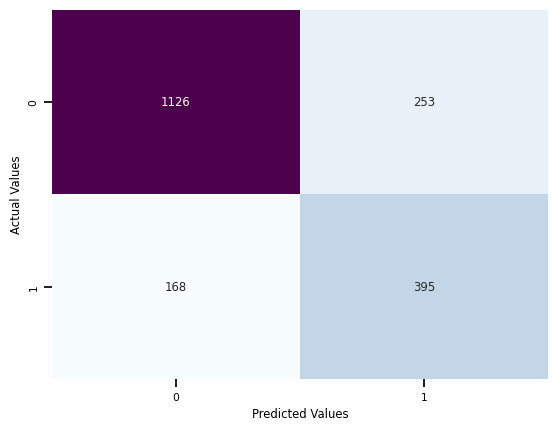

Classification report:
              precision    recall  f1-score   support

         0.0       0.87      0.82      0.84      1379
         1.0       0.61      0.70      0.65       563

    accuracy                           0.78      1942
   macro avg       0.74      0.76      0.75      1942
weighted avg       0.79      0.78      0.79      1942

Accuracy of the model:  0.7832131822863028


In [209]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [210]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


param_grid = {
    'n_estimators': [50, 100, 200,555,2000,2324,4545,9000],
    'learning_rate': [0.01, 0.1,0.5,0.8]
}


xg_boost = XGBClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=10),  # Base estimator
    random_state=10
)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=xg_boost,
    param_grid=param_grid,
    cv=5,  # Number of folds for cross-validation
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit(X_train_res, Y_train_res)

# Get the best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Use the best estimator for predictions
best_model = grid_search.best_estimator_
Y_pred = best_model.predict(X_test)


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

# Define the initial model with the maximum number of estimators
initial_n_estimators = 200
model_GradientBoosting = GradientBoostingClassifier(
    n_estimators=initial_n_estimators,
    random_state=10
)

# Split your training data into training and validation sets
X_train_sub, X_val, Y_train_sub, Y_val = train_test_split(X_train_res, Y_train_res, test_size=0.2, random_state=42)

# Fit the initial model on the training subset
model_GradientBoosting.fit(X_train_sub, Y_train_sub)

# Initialize variables for early stopping
best_val_score = -np.inf
n_no_improvement = 0
early_stop_rounds = 10  # number of rounds with no improvement to stop training early
best_n_estimators = initial_n_estimators

# Iterate over staged predictions to implement early stopping
for i, y_pred in enumerate(model_GradientBoosting.staged_predict(X_val)):
    val_score = accuracy_score(Y_val, y_pred)
    if val_score > best_val_score:
        best_val_score = val_score
        n_no_improvement = 0
        best_n_estimators = i + 1
    else:
        n_no_improvement += 1
    if n_no_improvement >= early_stop_rounds:
        print(f"Early stopping at iteration {i + 1}")
        break

# Train the final model using the best number of estimators
final_model_GradientBoosting = GradientBoostingClassifier(
    n_estimators=best_n_estimators,
    random_state=10
)
final_model_GradientBoosting.fit(X_train_res, Y_train_res)

# Predict on the test set
Y_pred = final_model_GradientBoosting.predict(X_test)
print(f"Test Accuracy: {accuracy_score(Y_test, Y_pred)}")


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
model1 = LogisticRegression(random_state=42)
model2 = DecisionTreeClassifier(random_state=42)
model3 = SVC(probability=True, random_state=42)  # Enable probability for soft voting

In [ ]:
# Hard Voting Classifier
hard_voting = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svc', model3)],
    voting='hard'
)

# Soft Voting Classifier
soft_voting = VotingClassifier(
    estimators=[('lr', model1), ('dt', model2), ('svc', model3)],
    voting='soft'
)

In [ ]:
hard_voting.fit(X_train_res, Y_train_res)
Y_pred = hard_voting.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [ ]:
soft_voting.fit(X_train_res, Y_train_res)
Y_pred = hard_voting.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report:")

print(classification_report(Y_test,Y_pred))

acc=accuracy_score(Y_test,Y_pred)
print("Accuracy of the model: ",acc)

In [211]:
import pickle
model='model.pkl'
with open(model,'wb') as f:
  pickle.dump(final_model_AdaBoost,f)